🚀 Starting comprehensive review analysis of ecosystem services literature (Optimized)...
📚 Found 12 literature files
📁 File list: ['download2015u1576.txt', 'download2016u1778.txt', 'download2017u1835.txt', 'download2018u2138.txt', 'download2019u2465.txt', 'download2020u2763.txt', 'download2021u3285.txt', 'download2022u3387.txt', 'download2023u3338.txt', 'download2024u3618.txt', 'download2025u4149.txt', 'download2026u390.txt']
📊 Expected total number of articles based on file names: 30722
--------------------------------------------------------------------------------
✅ download2015u1576.txt: expected 1576 articles, actually parsed 1576 articles
✅ download2016u1778.txt: expected 1778 articles, actually parsed 1778 articles
✅ download2017u1835.txt: expected 1835 articles, actually parsed 1835 articles
✅ download2018u2138.txt: expected 2138 articles, actually parsed 2138 articles
✅ download2019u2465.txt: expected 2465 articles, actually parsed 2465 articles
✅ download2020u2763.txt: expect

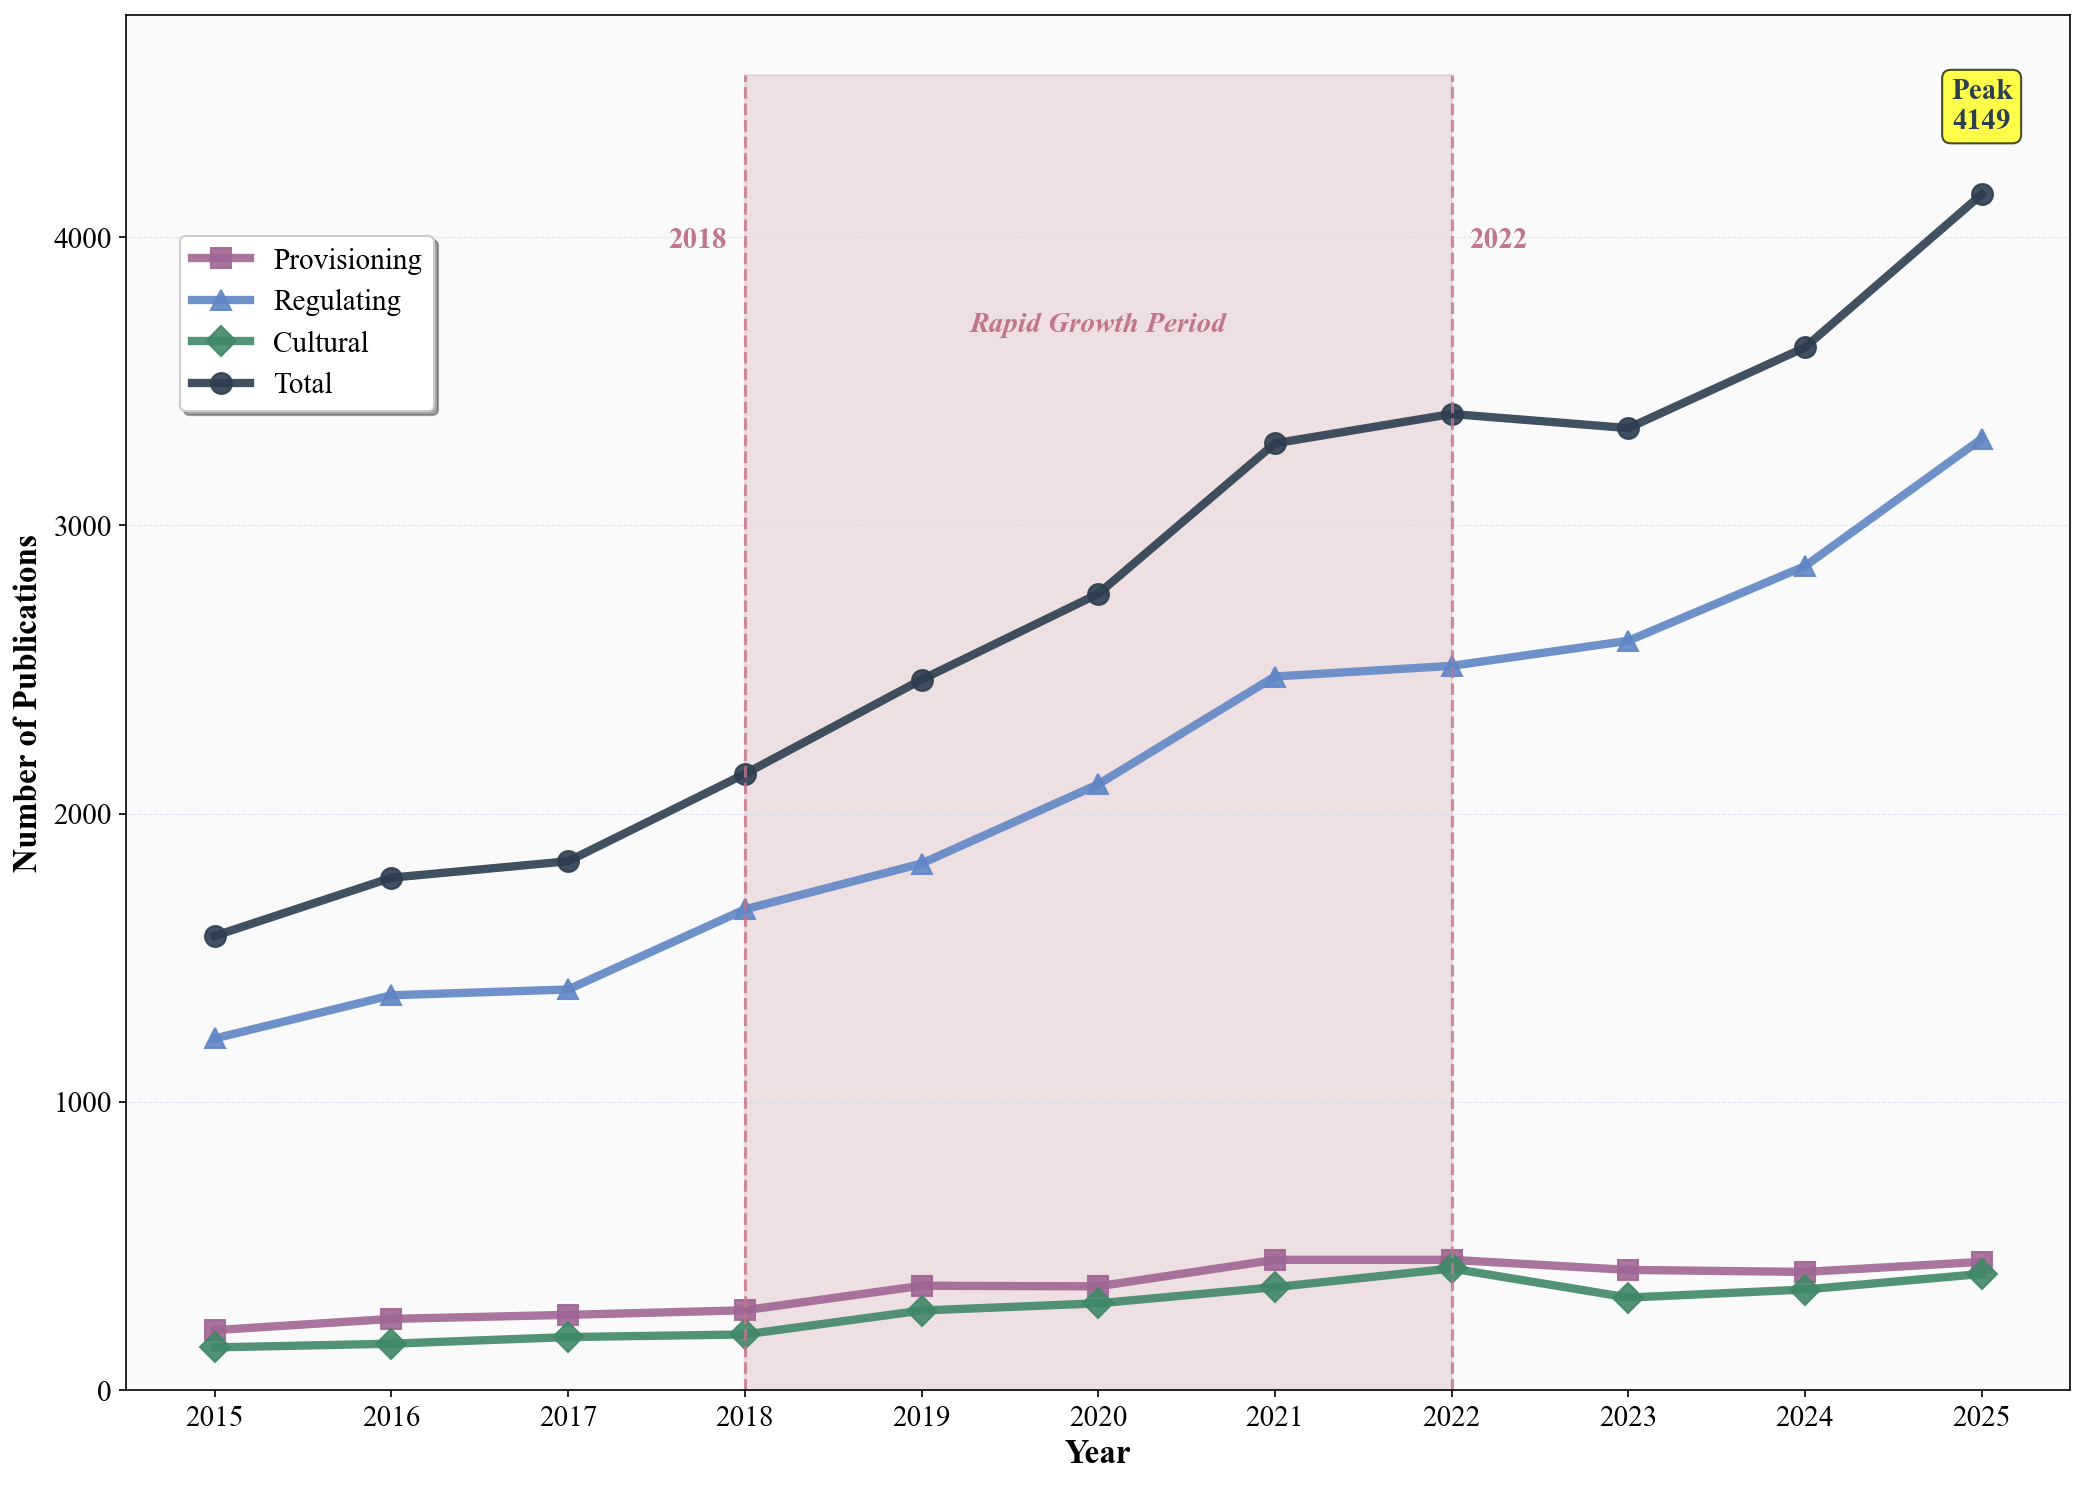

💾 Exporting analysis results...

✅ Comprehensive analysis results have been exported to ecosystem_services_comprehensive_review_optimized.xlsx

✅ Comprehensive analysis completed! Generated files:
  📊 ecosystem_services_trend_chart_optimized.pdf
  📁 ecosystem_services_comprehensive_review_optimized.xlsx


In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter, defaultdict
import numpy as np
import hashlib

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

class EcosystemServicesComprehensiveAnalyzer:
    def __init__(self, data_directory="./"):

        self.data_directory = data_directory
        self.all_articles = []  
        self.articles = [] 

        
    def generate_article_hash(self, article):
        identifier_parts = []
        if article.get('title'):
            title_cleaned = re.sub(r'\s+', ' ', article['title'].lower().strip())
            identifier_parts.append(title_cleaned)
        if article.get('year'):
            identifier_parts.append(article['year'])

        if article.get('authors') and len(article['authors']) > 0:
            first_author_cleaned = re.sub(r'\s+', ' ', article['authors'][0].lower().strip())
            identifier_parts.append(first_author_cleaned)

        if article.get('journal'):
            journal_cleaned = re.sub(r'\s+', ' ', article['journal'].lower().strip())
            identifier_parts.append(journal_cleaned)
        if len(identifier_parts) < 2:
            identifier_parts.append(str(hash(str(article))))
            
        identifier_string = '||'.join(identifier_parts)
        return hashlib.md5(identifier_string.encode('utf-8')).hexdigest()

    def read_literature_files(self):
        files = []
        expected_total = 0  
        
        for f in os.listdir(self.data_directory):
            if f.endswith('.txt') and 'download' in f and any(year in f for year in 
                ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']):
                files.append(f)
                match = re.search(r'u(\d+)\.txt', f)
                if match:
                    expected_total += int(match.group(1))
        
        files.sort()
        print(f"📚 Found {len(files)} literature files")
        print(f"📁 File list: {files}")
        print(f"📊 Expected total number of articles based on file names: {expected_total}")
        print("-" * 80)
        
        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    count = self.parse_articles(content, file)

                    match = re.search(r'u(\d+)\.txt', file)
                    expected = int(match.group(1)) if match else 0
                    status = "✅" if count == expected else "⚠️"
                    print(f"{status} {file}: expected {expected} articles, actually parsed {count} articles")
                    
            except Exception as e:
                print(f"❌ Error reading file {file}: {e}")
        
        print("-" * 80)
        print(f"📊 Statistics:")
        print(f"  - Total number of all articles: {len(self.all_articles)}")
        print(f"  - Articles with keywords: {len(self.articles)}")
        print(f"  - Expected total number of articles: {expected_total}")
        
        if len(self.all_articles) != expected_total:
            print(f"  ⚠️ Warning: the actual parsed total does not match the expected total! Difference: {len(self.all_articles) - expected_total}")
        
    def parse_articles(self, content, filename):
        articles = re.split(r'\nER\s*\n', content)
        file_article_count = 0
        
        for article_text in articles:
            if not article_text.strip():
                continue
            if not re.search(r'(^|\n)PT\s+', article_text):
                continue
            
            file_article_count += 1
            
            article_data = {
                'filename': filename,
                'keywords': set(), 
                'keywords_plus': set(), 
                'title': '',
                'year': '',
                'abstract': '',
                'journal': '',
                'authors': [],
                'citations': 0,
                'references': [],
                'cices_categories': [] 
            }

            id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if id_match:
                article_data['keywords_plus'].update(self.extract_keywords_from_field(id_match.group(1)))

            de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if de_match:
                article_data['keywords'].update(self.extract_keywords_from_field(de_match.group(1)))

            ti_match = re.search(r'\nTI\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ti_match:
                article_data['title'] = ti_match.group(1).replace('\n', ' ').strip()

            py_match = re.search(r'\nPY\s+(\d{4})', article_text)
            if py_match:
                article_data['year'] = py_match.group(1)

            ab_match = re.search(r'\nAB\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ab_match:
                article_data['abstract'] = ab_match.group(1).replace('\n', ' ').strip()

            so_match = re.search(r'\nSO\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if so_match:
                article_data['journal'] = so_match.group(1).replace('\n', ' ').strip()

            au_match = re.search(r'\nAU\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if au_match:
                authors = [author.strip() for author in au_match.group(1).split('\n') if author.strip()]
                article_data['authors'] = authors

            tc_match = re.search(r'\nTC\s+(\d+)', article_text)
            if tc_match:
                article_data['citations'] = int(tc_match.group(1))

            cg_match = re.search(r'\nCG\s+([^\n]+)', article_text)
            if cg_match:
                category = cg_match.group(1).strip().capitalize()
                article_data['cices_categories'].append(category)

            self.all_articles.append(article_data)

            if article_data['keywords'] or article_data['keywords_plus']:
                article_data['all_keywords'] = article_data['keywords'] | article_data['keywords_plus']
                self.articles.append(article_data)
        
        return file_article_count
                
    def extract_keywords_from_field(self, field_content):
        if not field_content:
            return []
            
        field_content = field_content.replace('\n', ' ')
        keywords = re.split(r'[;\n]', field_content)
        
        cleaned_keywords = []
        for keyword in keywords:
            keyword = keyword.strip().lower()
            keyword = re.sub(r'\s+', ' ', keyword)
            keyword = keyword.strip('.,;()[]{}"\'-')
            
            if keyword and len(keyword) > 2:
                cleaned_keywords.append(keyword)
                
        return cleaned_keywords
    
    def classify_articles_by_cices(self):
        classification_results = {
            'Provisioning': [],
            'Regulating': [],
            'Cultural': []
        }

        added_articles = {
            'Provisioning': set(),
            'Regulating': set(), 
            'Cultural': set()
        }

        for article in self.articles:
            article_hash = self.generate_article_hash(article)
            for category in article.get('cices_categories', []):
                if category in classification_results:
                    if article_hash not in added_articles[category]:
                        classification_results[category].append(article)
                        added_articles[category].add(article_hash)

        print(f"\n🔍 CICES classification statistics (read directly from file attributes):")
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            count = len(classification_results[category])
            print(f"  - {category}: {count} articles")
        
        return classification_results


    def calculate_total_cices_articles(self, classification_results):
        all_cices_hashes = set()
        
        for category, articles in classification_results.items():
            for article in articles:
                article_hash = self.generate_article_hash(article)
                all_cices_hashes.add(article_hash)
        
        return len(all_cices_hashes)
    
    def analyze_yearly_distribution(self):
        yearly_stats = defaultdict(lambda: {
            'total': 0,
            'cices_main_counts': defaultdict(int),
            'articles': []
        })
        
        for article in self.articles:
            year = article['year']
            if not year:
                year = 'Unknown'
            
            yearly_stats[year]['total'] += 1
            yearly_stats[year]['articles'].append(article)

            for category in article.get('cices_categories', []):
                yearly_stats[year]['cices_main_counts'][category] += 1
        
        return yearly_stats
    
    def analyze_keyword_patterns(self):
        all_keywords = Counter()
        de_keywords = Counter() 
        id_keywords = Counter()
        
        for article in self.articles:
            for keyword in article['keywords']:
                all_keywords[keyword] += 1
                de_keywords[keyword] += 1

            for keyword in article['keywords_plus']:
                all_keywords[keyword] += 1
                id_keywords[keyword] += 1
        
        return all_keywords, de_keywords, id_keywords
    
    def analyze_journal_distribution(self):
        journals = set()
        for article in self.articles:
            if article['journal']:
                journals.add(article['journal'].lower().strip())
        
        journal_counts = Counter()
        for article in self.articles:
            if article['journal']:
                normalized_journal = article['journal'].lower().strip()
                journal_counts[normalized_journal] += 1
        
        print(f"Total number of journals: {len(journals)}")
        return journal_counts
    
    def create_line_chart(self, yearly_stats, main_categories_count):
        valid_years = [str(year) for year in range(2015, 2026)]
        sorted_years = [year for year in valid_years if year in yearly_stats and yearly_stats[year]['total'] > 0]
        
        if not sorted_years:
            print("No valid year data available for visualization")
            return

        data = {
            'Year': [int(year) for year in sorted_years],
            'Total': [yearly_stats[year]['total'] for year in sorted_years],
            'Provisioning': [yearly_stats[year]['cices_main_counts'].get('Provisioning', 0) for year in sorted_years],
            'Regulating': [yearly_stats[year]['cices_main_counts'].get('Regulating', 0) for year in sorted_years],
            'Cultural': [yearly_stats[year]['cices_main_counts'].get('Cultural', 0) for year in sorted_years]
        }

        fig, ax = plt.subplots(figsize=(14, 10), dpi=150)

        categories = ['Provisioning', 'Regulating', 'Cultural', 'Total']
        colors = ['#A06593', '#6086C5', '#408868', '#2C3E50'] 

        markers = ['s', '^', 'D', 'o'] 
        
        x = data['Year']
        
        for i, category in enumerate(categories):
            y = data[category]
            ax.plot(x, y, marker=markers[i], label=category, linewidth=4, markersize=10, 
                   color=colors[i], alpha=0.9)

        if len(x) > 0:
            y_max = max(max(data[cat]) for cat in categories)

            if len(x) >= 5:
                start_highlight = x[len(x)//3]
                end_highlight = x[2*len(x)//3]
                
                ax.fill_betweenx([0, y_max * 1.1], start_highlight, end_highlight, 
                               color="#c2768b", alpha=0.2)
                ax.plot([start_highlight, start_highlight], [0, y_max * 1.1], 
                       color="#c2768b", linestyle="--", alpha=0.8)
                ax.text(start_highlight - 0.1, y_max * 0.95, str(start_highlight), 
                       ha="right", va="bottom", color="#c2768b", fontweight='bold', fontsize=14)
                ax.plot([end_highlight, end_highlight], [0, y_max * 1.1], 
                       color="#c2768b", linestyle="--", alpha=0.8)
                ax.text(end_highlight + 0.1, y_max * 0.95, str(end_highlight), 
                       ha="left", va="bottom", color="#c2768b", fontweight='bold', fontsize=14)
                ax.text((start_highlight + end_highlight) / 2, y_max * 0.88, 
                       "Rapid Growth Period", ha="center", va="bottom", 
                       color="#c2768b", fontweight='bold', style='italic', fontsize=14)

        total_values = data['Total']
        if total_values:
            peak_idx = total_values.index(max(total_values))
            peak_year = data['Year'][peak_idx]
            peak_value = total_values[peak_idx]
            ax.text(peak_year, peak_value * 1.05, f"Peak\n{peak_value}", 
                   ha="center", va="bottom", color="#2C3E50", fontweight='bold', 
                   fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

        ax.set_title("", 
                    fontsize=20, fontweight='bold', loc='left', x=0.02, y=0.95)
        ax.set_xlabel("Year", fontsize=16, fontweight='bold')
        ax.set_ylabel("Number of Publications", fontsize=16, fontweight='bold')

        if x:
            ax.set_xlim(min(x) - 0.5, max(x) + 0.5)
            if total_values:
                ax.set_ylim(0, max(total_values) * 1.15)

        ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.85), frameon=True, 
                 fancybox=True, shadow=True, fontsize=14)

        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}"))

        ax.grid(which="major", axis="y", linestyle="--", linewidth=0.5, color="#d3dce8", alpha=0.7)
        ax.set_facecolor('#fafafa')
        
        plt.tight_layout()
        plt.savefig('ecosystem_services_trend_chart_optimized.pdf',
                    dpi=1200,
                    bbox_inches='tight',
                    transparent=False)
        plt.show()
    
    def generate_comprehensive_report(self, yearly_stats, all_keywords, journal_counts,
                                    main_categories_count, de_keywords, id_keywords, 
                                    total_cices_articles):
        print("\n" + "="*80)
        print("🌍 Comprehensive Review Report of Ecosystem Services Literature (Optimized)")
        print("="*80)

        print(f"\n📊 I. Overall Statistics")
        print(f"  ├─ Total number of all articles: {len(self.all_articles)}")
        print(f"  ├─ Number of articles with keywords: {len(self.articles)}") 
        print(f"  ├─ Proportion of articles with keywords: {len(self.articles)/len(self.all_articles)*100:.2f}%")
        print(f"  ├─ Total number of articles with CICES classification (deduplicated): {total_cices_articles}")
        print(f"  └─ CICES classification coverage rate: {total_cices_articles/len(self.articles)*100:.2f}%")

        print(f"\n📋 Keyword field statistics:")
        de_count = len(de_keywords)
        id_count = len(id_keywords)
        print(f"  ├─ Number of DE field keywords: {de_count}")
        print(f"  ├─ Number of ID field keywords: {id_count}")
        print(f"  └─ Total number of keywords (deduplicated): {len(all_keywords)}")

        print(f"\n🌳 II. CICES Classification Statistics (Optimized Deduplication)")
        print(f"{'Main Category':<15} {'Articles':<10} {'% of Total':<12} {'% of CICES':<12}")
        print("-" * 55)
        for category, count in main_categories_count.items():
            percentage_total = (count / len(self.articles)) * 100
            percentage_cices = (count / total_cices_articles) * 100 if total_cices_articles > 0 else 0
            print(f"{category:<15} {count:<10} {percentage_total:<12.1f} {percentage_cices:<12.1f}")

        valid_years = [str(year) for year in range(2015, 2026)]
        sorted_years = [year for year in valid_years if year in yearly_stats]
        if 'Unknown' in yearly_stats:
            sorted_years.append('Unknown')
        
        print(f"\n📈 III. Yearly Distribution Statistics")
        print(f"{'Year':<8} {'Articles':<8} {'Prov':<8} {'Reg':<8} {'Cult':<8} {'Percent(%)':<10}")
        print("-" * 55)
        
        for year in sorted_years:
            stats = yearly_stats[year]
            count = stats['total']
            prov_count = stats.get('cices_main_counts', {}).get('Provisioning', 0)
            reg_count = stats.get('cices_main_counts', {}).get('Regulating', 0)
            cult_count = stats.get('cices_main_counts', {}).get('Cultural', 0)
            percentage = (count / len(self.articles)) * 100
            print(f"{year:<8} {count:<8} {prov_count:<8} {reg_count:<8} {cult_count:<8} {percentage:<10.1f}")

        print(f"\n🏷️ IV. High-Frequency Keyword Analysis (Top 70)")
        print(f"{'Rank':<6} {'Keyword':<40} {'Frequency':<8} {'Source':<8}")
        print("-" * 70)
        for i, (keyword, count) in enumerate(all_keywords.most_common(70), 1):
            source = ""
            if keyword in de_keywords:
                source += "DE"
            if keyword in id_keywords:
                source += ("+" if source else "") + "ID"
            print(f"{i:<6} {keyword[:38]:<40} {count:<8} {source:<8}")

        print(f"\n📚 V. Main Publishing Journals (Top 10)")
        print(f"{'Rank':<6} {'Journal Name':<50} {'Articles':<8}")
        print("-" * 70)
        for i, (journal, count) in enumerate(journal_counts.most_common(10), 1):
            print(f"{i:<6} {journal[:48]:<50} {count:<8}")
        
        return sorted_years
    
    def export_comprehensive_results(self, yearly_stats, all_keywords, 
                                    journal_counts, sorted_years,
                                    main_categories_count, de_keywords, id_keywords,
                                    total_cices_articles):
        with pd.ExcelWriter('./ecosystem_services_comprehensive_review_optimized.xlsx', engine='openpyxl') as writer:

            summary_data = {
                'Metric': ['Total number of all articles', 'Number of articles with keywords', 'Proportion of articles with keywords (%)', 
                          'Total number of articles with CICES classification (deduplicated)', 'CICES classification coverage rate (%)',
                          'Number of years covered', 'Average number of articles per year',
                          'Number of Provisioning articles', 'Number of Regulating articles', 'Number of Cultural articles',
                          'Number of DE field keywords', 'Number of ID field keywords', 'Total number of keywords (deduplicated)'],
                'Value': [
                    len(self.all_articles),
                    len(self.articles),
                    round(len(self.articles)/len(self.all_articles)*100, 2),
                    total_cices_articles,
                    round(total_cices_articles/len(self.articles)*100, 2),
                    len([y for y in sorted_years if y != 'Unknown']),
                    round(len(self.articles)/len([y for y in sorted_years if y != 'Unknown']), 1) if len([y for y in sorted_years if y != 'Unknown']) > 0 else 0,
                    main_categories_count.get('Provisioning', 0),
                    main_categories_count.get('Regulating', 0),
                    main_categories_count.get('Cultural', 0),
                    len(de_keywords),
                    len(id_keywords),
                    len(all_keywords)
                ]
            }
            summary_df = pd.DataFrame(summary_data)
            summary_df.to_excel(writer, sheet_name='Overall Statistics', index=False)

            yearly_data = []
            for year in sorted_years:
                yearly_data.append({
                    'Year': year,
                    'Articles': yearly_stats[year]['total'],
                    'Percentage': round((yearly_stats[year]['total']/len(self.articles))*100, 2),
                    'Provisioning': yearly_stats[year]['cices_main_counts'].get('Provisioning', 0),
                    'Regulating': yearly_stats[year]['cices_main_counts'].get('Regulating', 0),
                    'Cultural': yearly_stats[year]['cices_main_counts'].get('Cultural', 0)
                })
            yearly_df = pd.DataFrame(yearly_data)
            yearly_df.to_excel(writer, sheet_name='Yearly Distribution', index=False)

            keyword_data = []
            for keyword, count in all_keywords.most_common(200):
                source = ""
                if keyword in de_keywords:
                    source += "DE"
                if keyword in id_keywords:
                    source += ("+" if source else "") + "ID"
                
                keyword_data.append({
                    'Keyword': keyword,
                    'Frequency': count,
                    'Percentage': round((count/len(self.articles))*100, 2),
                    'Source': source,
                    'DE_Frequency': de_keywords.get(keyword, 0),
                    'ID_Frequency': id_keywords.get(keyword, 0)
                })
            keyword_df = pd.DataFrame(keyword_data)
            keyword_df.to_excel(writer, sheet_name='High-Frequency Keywords', index=False)

            journal_data = []
            for journal, count in journal_counts.most_common():
                journal_data.append({
                    'Journal': journal,
                    'Articles': count,
                    'Percentage': round((count/len(self.articles))*100, 2)
                })
            journal_df = pd.DataFrame(journal_data)
            journal_df.to_excel(writer, sheet_name='Journal Distribution', index=False)
        
        print("\n✅ Comprehensive analysis results have been exported to ecosystem_services_comprehensive_review_optimized.xlsx")
    
    def run_comprehensive_analysis(self):
        """Run the complete comprehensive analysis workflow"""
        print("🚀 Starting comprehensive review analysis of ecosystem services literature (Optimized)...")
        print("="*80)
        
        # Step 1: Read literature
        self.read_literature_files()
        
        if not self.all_articles:
            print("❌ No valid article data found!")
            return
        
        if not self.articles:
            print("❌ No articles with keywords found!")
            return
        
        print(f"\n📊 WOS search already ensures all articles are ecosystem service related; directly analyzing {len(self.articles)} articles with keywords")

        print("\n📊 Performing CICES classification (using optimized deduplication logic)...")
        classification_results = self.classify_articles_by_cices()

        main_categories_count = {}
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            main_categories_count[category] = len(classification_results[category])

        total_cices_articles = self.calculate_total_cices_articles(classification_results)
        
        print(f"Classification results: Provisioning={main_categories_count.get('Provisioning', 0)}, "
              f"Regulating={main_categories_count.get('Regulating', 0)}, "
              f"Cultural={main_categories_count.get('Cultural', 0)}")
        print(f"Total number of articles with CICES classification (deduplicated): {total_cices_articles}")

        print("📊 Analyzing yearly distribution...")
        yearly_stats = self.analyze_yearly_distribution()

        print("🔍 Analyzing keyword patterns...")
        all_keywords, de_keywords, id_keywords = self.analyze_keyword_patterns()

        print("📚 Analyzing journal distribution...")
        journal_counts = self.analyze_journal_distribution()

        sorted_years = self.generate_comprehensive_report(
            yearly_stats, all_keywords, journal_counts,
            main_categories_count, de_keywords, id_keywords, total_cices_articles
        )

        print("\n📊 Creating visualization charts...")
        self.create_line_chart(yearly_stats, main_categories_count)
        
        print("💾 Exporting analysis results...")
        self.export_comprehensive_results(
            yearly_stats, all_keywords, journal_counts, sorted_years,
            main_categories_count, de_keywords, id_keywords, total_cices_articles
        )
        
        print("\n" + "="*80)
        print("✅ Comprehensive analysis completed! Generated files:")
        print("  📊 ecosystem_services_trend_chart_optimized.pdf")
        print("  📁 ecosystem_services_comprehensive_review_optimized.xlsx")
        print("="*80)

if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = EcosystemServicesComprehensiveAnalyzer(data_directory=TARGET_DIR)
    analyzer.run_comprehensive_analysis()

🚀 Starting Ecosystem Services Bibliometric Analysis (Optimized)...
📚 Found 12 literature files
✅ Parsed 30722 articles in total
✅ Articles with keywords: 30722

📊 WOS search already ensures all articles are ecosystem service related
📊 Analyzing 30722 articles with keywords

📊 Performing CICES classification with optimized matching and deduplication...

🔍 CICES classification statistics (read directly from file attributes):
  - Provisioning: 3940 articles
  - Regulating: 23628 articles
  - Cultural: 3154 articles
Classification results: Provisioning=3940, Regulating=23628, Cultural=3154
Total number of articles with CICES classification (optimized deduplication): 30722
📊 Calculating overall bibliometric indicators...
📊 Calculating CICES category bibliometric indicators...

📊 Ecosystem Services Bibliometric Analysis Report (Optimized)

📊 CICES Classification Summary (Optimized Deduplication)
------------------------------------------------------------
Total Articles with Keywords: 30722


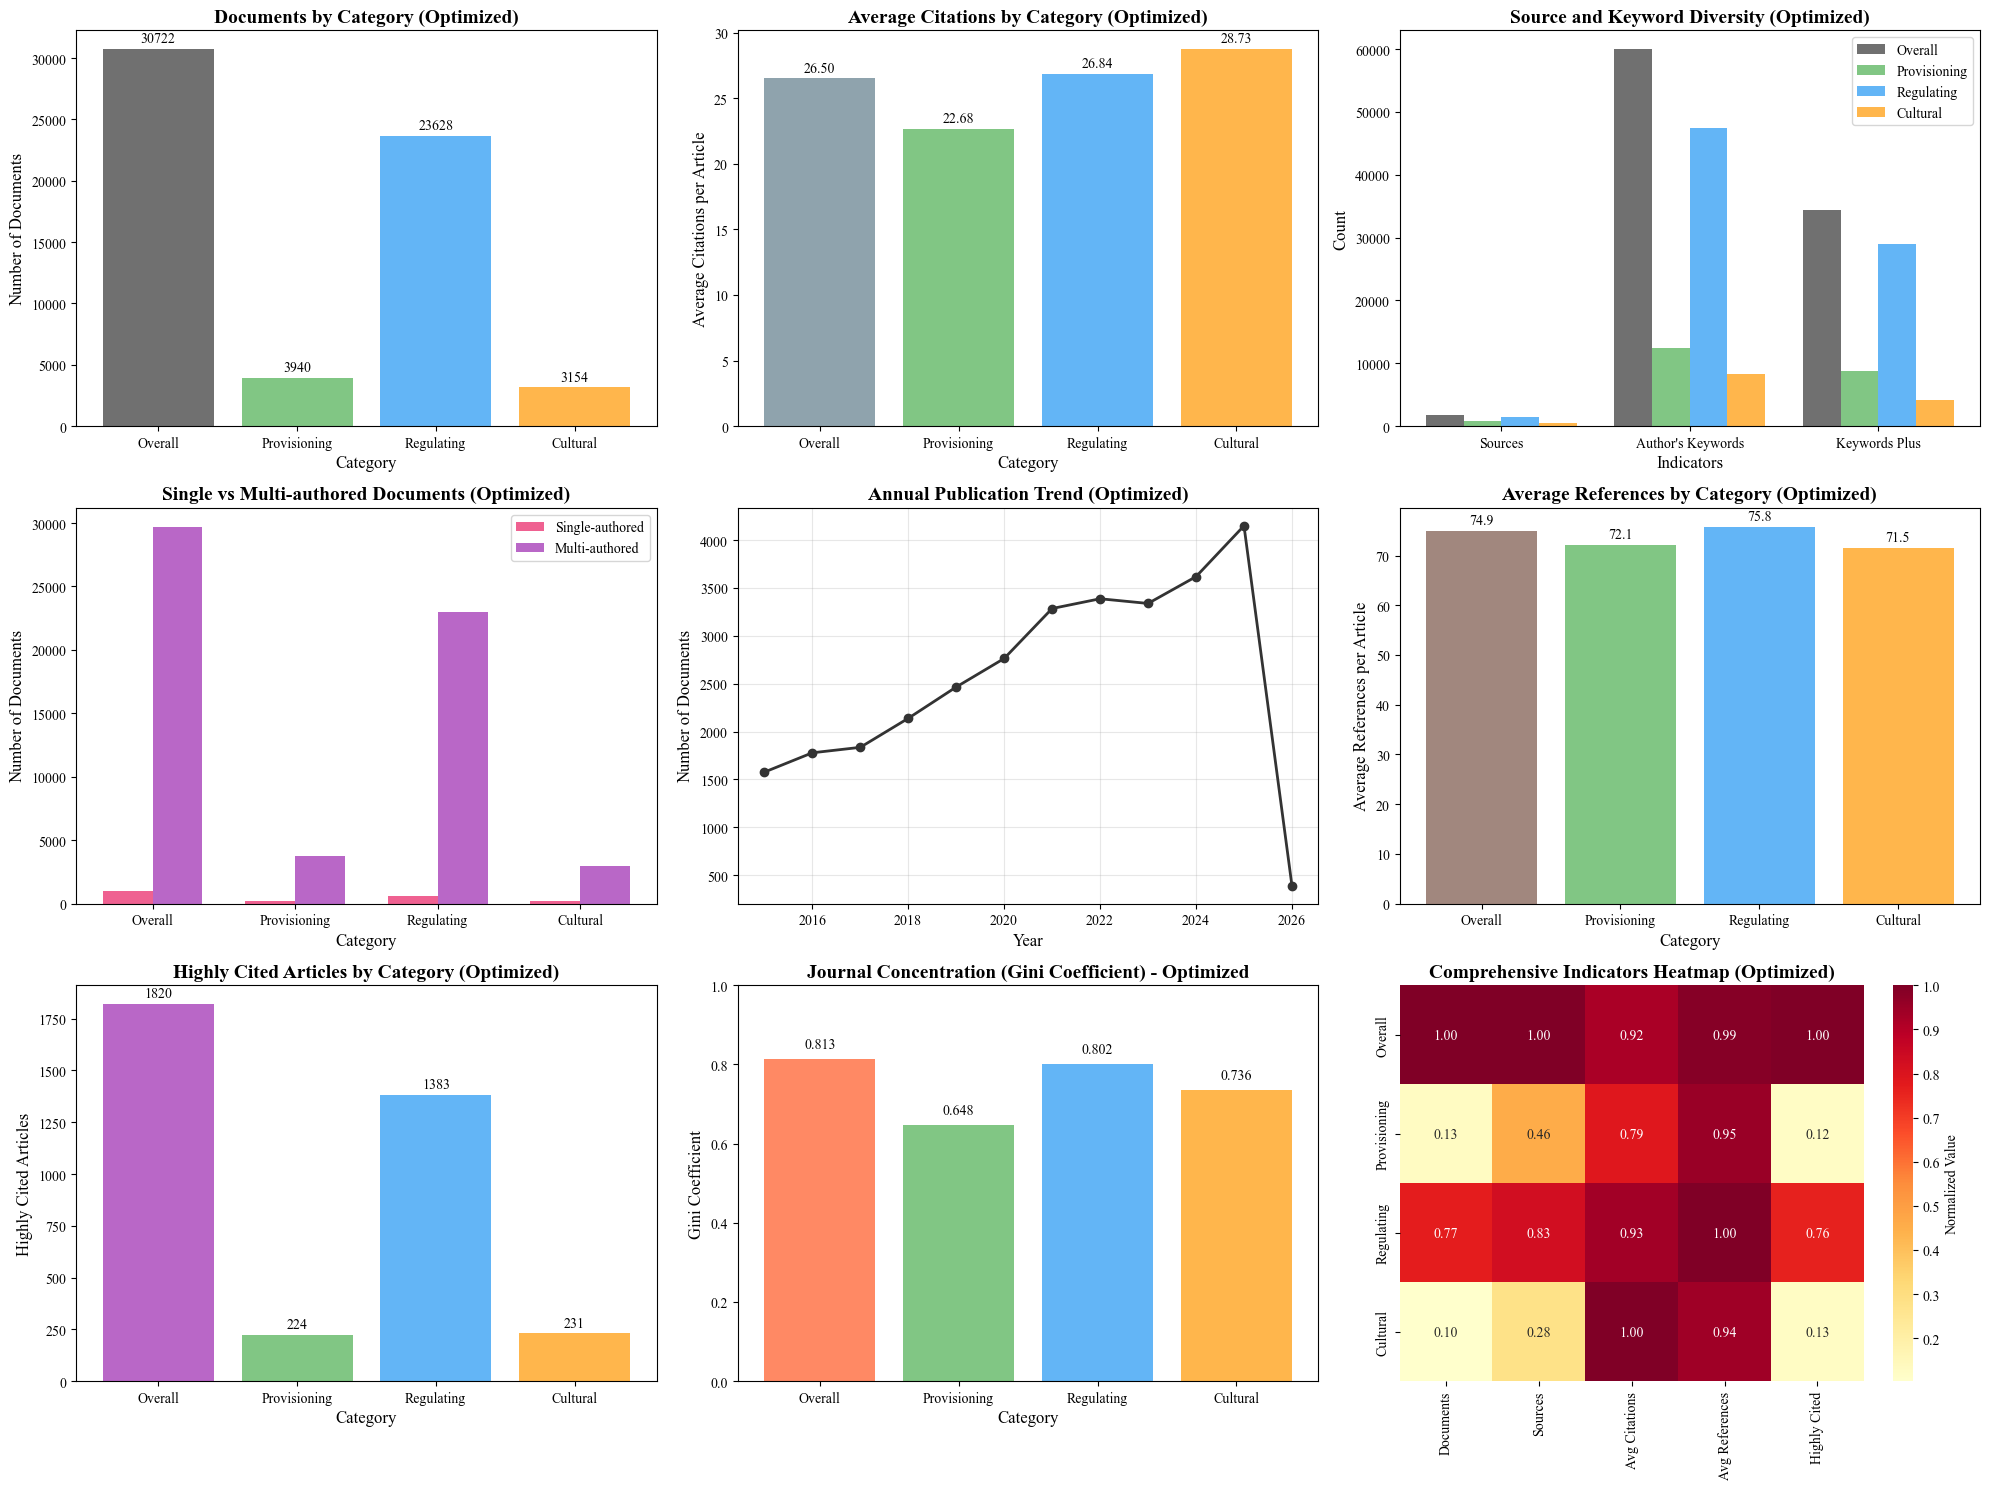

💾 Exporting analysis results...

✅ Bibliometric analysis results (optimized) exported to bibliometric_analysis_optimized.xlsx

✅ Bibliometric analysis (optimized) completed! Generated files:
  📊 bibliometric_analysis_optimized.png
  📁 bibliometric_analysis_optimized.xlsx


In [2]:
import os
import re
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

class EcosystemServicesBibliometricAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.all_articles = []
        self.articles = [] 
        
    def generate_article_hash(self, article):
        """Generate a unique article identifier for deduplication - optimized version"""
        identifier_parts = []

        if article.get('title'):
            title_cleaned = re.sub(r'\s+', ' ', article['title'].lower().strip())
            identifier_parts.append(title_cleaned)

        if article.get('year'):
            identifier_parts.append(article['year'])

        if article.get('authors') and len(article['authors']) > 0:
            first_author_cleaned = re.sub(r'\s+', ' ', article['authors'][0].lower().strip())
            identifier_parts.append(first_author_cleaned)

        if article.get('journal'):
            journal_cleaned = re.sub(r'\s+', ' ', article['journal'].lower().strip())
            identifier_parts.append(journal_cleaned)

        if len(identifier_parts) < 2:
            identifier_parts.append(str(hash(str(article))))
            
        identifier_string = '||'.join(identifier_parts)
        return hashlib.md5(identifier_string.encode('utf-8')).hexdigest()

    def read_literature_files(self):
        """Read all literature files"""
        files = []
        for f in os.listdir(self.data_directory):
            if f.endswith('.txt') and 'download' in f and any(year in f for year in 
                ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']):
                files.append(f)
        
        files.sort()
        print(f"📚 Found {len(files)} literature files")
        
        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    self.parse_articles(content, file)
            except Exception as e:
                print(f"❌ Error reading file {file}: {e}")
        
        print(f"✅ Parsed {len(self.all_articles)} articles in total")
        print(f"✅ Articles with keywords: {len(self.articles)}")
        
    def parse_articles(self, content, filename):
        """Parse article content and extract complete information"""
        articles = re.split(r'\nER\s*\n', content)
        
        for article_text in articles:
            if not article_text.strip():
                continue

            if not re.search(r'(^|\n)PT\s+', article_text):
                continue
            
            article_data = {
                'filename': filename,
                'keywords': set(), 
                'keywords_plus': set(),
                'title': '',
                'year': '',
                'abstract': '',
                'journal': '',
                'authors': [],
                'author_count': 0, 
                'citations': 0,
                'reference_count': 0,
                'cices_categories': [] 
            }

            id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if id_match:
                id_content = id_match.group(1)
                keywords_plus = self.extract_keywords_from_field(id_content)
                article_data['keywords_plus'].update(keywords_plus)

            de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if de_match:
                de_content = de_match.group(1)
                keywords = self.extract_keywords_from_field(de_content)
                article_data['keywords'].update(keywords)

            ti_match = re.search(r'\nTI\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ti_match:
                article_data['title'] = ti_match.group(1).replace('\n', ' ').strip()

            py_match = re.search(r'\nPY\s+(\d{4})', article_text)
            if py_match:
                article_data['year'] = py_match.group(1)

            ab_match = re.search(r'\nAB\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ab_match:
                article_data['abstract'] = ab_match.group(1).replace('\n', ' ').strip()

            so_match = re.search(r'\nSO\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if so_match:
                article_data['journal'] = so_match.group(1).replace('\n', ' ').strip()

            au_match = re.search(r'\nAU\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if au_match:
                authors_text = au_match.group(1)
                authors = [author.strip() for author in authors_text.split('\n') if author.strip()]
                article_data['authors'] = authors
                article_data['author_count'] = len(authors)

            tc_match = re.search(r'\nTC\s+(\d+)', article_text)
            if tc_match:
                article_data['citations'] = int(tc_match.group(1))

            nr_match = re.search(r'\nNR\s+(\d+)', article_text)
            if nr_match:
                article_data['reference_count'] = int(nr_match.group(1))

            cg_match = re.search(r'\nCG\s+([^\n]+)', article_text)
            if cg_match:
                category = cg_match.group(1).strip().capitalize()
                article_data['cices_categories'].append(category)

            self.all_articles.append(article_data)

            if article_data['keywords'] or article_data['keywords_plus']:
                article_data['all_keywords'] = article_data['keywords'] | article_data['keywords_plus']
                self.articles.append(article_data)
                
    def extract_keywords_from_field(self, field_content):
        """Extract keywords from ID or DE field content (kept for high-frequency word indicator analysis)"""
        if not field_content:
            return []
            
        field_content = field_content.replace('\n', ' ')
        keywords = re.split(r'[;\n]', field_content)
        
        cleaned_keywords = []
        for keyword in keywords:
            keyword = keyword.strip().lower()
            keyword = re.sub(r'\s+', ' ', keyword)
            keyword = keyword.strip('.,;()[]{}"\'-')
            
            if keyword and len(keyword) > 2:
                cleaned_keywords.append(keyword)
                
        return cleaned_keywords
        
    def classify_articles_by_cices(self):
        """Directly classify based on the literature's own CG field, mapping to the original three major categories"""
        classification_results = {
            'Provisioning': [],
            'Regulating': [],
            'Cultural': []
        }

        added_articles = {
            'Provisioning': set(),
            'Regulating': set(), 
            'Cultural': set()
        }

        for article in self.articles:
            article_hash = self.generate_article_hash(article)
            for category in article.get('cices_categories', []):
                if category in classification_results:
                    if article_hash not in added_articles[category]:
                        classification_results[category].append(article)
                        added_articles[category].add(article_hash)

        print(f"\n🔍 CICES classification statistics (read directly from file attributes):")
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            count = len(classification_results[category])
            print(f"  - {category}: {count} articles")
        
        return classification_results
    
    def calculate_total_cices_articles(self, classification_results):
        """Calculate the total number of articles with CICES classification (deduplicated)"""
        all_cices_hashes = set()
        
        for category, articles in classification_results.items():
            for article in articles:
                article_hash = self.generate_article_hash(article)
                all_cices_hashes.add(article_hash)
        
        return len(all_cices_hashes)

    def calculate_bibliometric_indicators(self, articles, category_name="Overall Literature"):
        """Calculate bibliometric indicators - optimized version"""
        if not articles:
            return None
        
        indicators = {}

        indicators['Documents'] = len(articles)

        journals = set()
        for article in articles:
            if article['journal']:
                journals.add(article['journal'].lower().strip())
        indicators['Sources'] = len(journals)

        author_keywords = set()
        for article in articles:
            author_keywords.update(article['keywords'])
        indicators['Authors_Keywords'] = len(author_keywords)

        keywords_plus = set()
        for article in articles:
            keywords_plus.update(article['keywords_plus'])
        indicators['Keywords_Plus_ID'] = len(keywords_plus)

        years = []
        for article in articles:
            if article['year'] and article['year'].isdigit():
                years.append(int(article['year']))
        if years:
            indicators['Period'] = f"{min(years)}-{max(years)}"
            indicators['Years_Span'] = max(years) - min(years) + 1
        else:
            indicators['Period'] = "Unknown"
            indicators['Years_Span'] = 0

        single_authored = 0
        multi_authored = 0
        for article in articles:
            if article['author_count'] == 1:
                single_authored += 1
            elif article['author_count'] > 1:
                multi_authored += 1
        indicators['Single_Authored_Docs'] = single_authored
        indicators['Multi_Authored_Docs'] = multi_authored

        total_citations = sum(article['citations'] for article in articles)
        indicators['Total_Citations'] = total_citations
        if indicators['Documents'] > 0:
            indicators['Avg_Citations_per_Article'] = round(
                total_citations / indicators['Documents'], 2
            )
        else:
            indicators['Avg_Citations_per_Article'] = 0

        total_references = sum(article['reference_count'] for article in articles)
        indicators['Total_References'] = total_references
        if indicators['Documents'] > 0:
            indicators['Avg_References_per_Article'] = round(
                total_references / indicators['Documents'], 2
            )
        else:
            indicators['Avg_References_per_Article'] = 0

        citations_list = [article['citations'] for article in articles]
        if citations_list:
            indicators['Max_Citations'] = max(citations_list)
            indicators['Min_Citations'] = min(citations_list)
            indicators['Median_Citations'] = np.median(citations_list)
        else:
            indicators['Max_Citations'] = 0
            indicators['Min_Citations'] = 0
            indicators['Median_Citations'] = 0

        if citations_list and len(citations_list) > 1:
            mean_citations = np.mean(citations_list)
            std_citations = np.std(citations_list)
            highly_cited_threshold = mean_citations + std_citations
            indicators['Highly_Cited_Threshold'] = round(highly_cited_threshold, 2)
            indicators['Highly_Cited_Articles'] = sum(1 for c in citations_list if c > highly_cited_threshold)
        else:
            indicators['Highly_Cited_Threshold'] = 0
            indicators['Highly_Cited_Articles'] = 0

        if years:
            indicators['Avg_Articles_per_Year'] = round(len(articles) / indicators['Years_Span'], 2)
            year_distribution = Counter(years)
            indicators['Most_Productive_Year'] = year_distribution.most_common(1)[0][0]
            indicators['Max_Articles_per_Year'] = year_distribution.most_common(1)[0][1]
        else:
            indicators['Avg_Articles_per_Year'] = 0
            indicators['Most_Productive_Year'] = 'Unknown'
            indicators['Max_Articles_per_Year'] = 0

        journal_distribution = Counter()
        for article in articles:
            if article['journal']:
                journal_distribution[article['journal'].lower().strip()] += 1
        
        if journal_distribution:
            indicators['Most_Productive_Journal'] = journal_distribution.most_common(1)[0][0]
            indicators['Max_Articles_per_Journal'] = journal_distribution.most_common(1)[0][1]
            journal_counts = list(journal_distribution.values())
            journal_counts.sort()
            n = len(journal_counts)
            if n > 1:
                index = np.arange(1, n + 1)
                gini = (2 * np.sum(index * journal_counts)) / (n * np.sum(journal_counts)) - (n + 1) / n
                indicators['Journal_Concentration_Gini'] = round(gini, 3)
            else:
                indicators['Journal_Concentration_Gini'] = 0
        else:
            indicators['Most_Productive_Journal'] = 'Unknown'
            indicators['Max_Articles_per_Journal'] = 0
            indicators['Journal_Concentration_Gini'] = 0
        
        return indicators
    
    def generate_bibliometric_report(self, overall_indicators, cices_indicators, total_cices_articles):
        """Generate bibliometric report - optimized version"""
        print("\n" + "="*80)
        print("📊 Ecosystem Services Bibliometric Analysis Report (Optimized)")
        print("="*80)

        indicator_names = {
            'Documents': 'Documents',
            'Sources': 'Sources (Journals)',
            'Authors_Keywords': "Author's Keywords",
            'Keywords_Plus_ID': 'Keywords Plus (ID)',
            'Period': 'Period',
            'Years_Span': 'Years Span',
            'Single_Authored_Docs': 'Single-Authored Documents',
            'Multi_Authored_Docs': 'Multi-Authored Documents',
            'Total_Citations': 'Total Citations',
            'Avg_Citations_per_Article': 'Average Citations per Article',
            'Total_References': 'Total References',
            'Avg_References_per_Article': 'Average References per Article',
            'Max_Citations': 'Maximum Citations',
            'Min_Citations': 'Minimum Citations',
            'Median_Citations': 'Median Citations',
            'Highly_Cited_Threshold': 'Highly Cited Threshold',
            'Highly_Cited_Articles': 'Highly Cited Articles',
            'Avg_Articles_per_Year': 'Average Articles per Year',
            'Most_Productive_Year': 'Most Productive Year',
            'Max_Articles_per_Year': 'Max Articles per Year',
            'Most_Productive_Journal': 'Most Productive Journal',
            'Max_Articles_per_Journal': 'Max Articles per Journal',
            'Journal_Concentration_Gini': 'Journal Concentration (Gini)'
        }

        print(f"\n📊 CICES Classification Summary (Optimized Deduplication)")
        print("-" * 60)
        print(f"Total Articles with Keywords: {len(self.articles)}")
        print(f"Articles with CICES Classification (Deduplicated): {total_cices_articles}")
        print(f"CICES Coverage Rate: {(total_cices_articles/len(self.articles)*100):.2f}%")
        
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            if category in cices_indicators and cices_indicators[category]:
                count = cices_indicators[category]['Documents']
                rate = (count/len(self.articles)*100)
                print(f"{category} Services: {count} articles ({rate:.2f}%)")

        print("\n📈 I. Overall Bibliometric Indicators")
        print("-" * 60)
        print(f"{'Indicator':<35} {'Value':<25}")
        print("-" * 60)
        for key, value in overall_indicators.items():
            name = indicator_names.get(key, key)
            print(f"{name:<35} {str(value):<25}")

        for category in ['Provisioning', 'Regulating', 'Cultural']:
            if category in cices_indicators and cices_indicators[category]:
                print(f"\n📊 {category} Services Bibliometric Indicators")
                print("-" * 60)
                print(f"{'Indicator':<35} {'Value':<25}")
                print("-" * 60)
                for key, value in cices_indicators[category].items():
                    name = indicator_names.get(key, key)
                    print(f"{name:<35} {str(value):<25}")

        print("\n📊 CICES Categories Comparison (Optimized)")
        print("-" * 100)
        print(f"{'Indicator':<30} {'Overall':<15} {'Provisioning':<15} {'Regulating':<15} {'Cultural':<15}")
        print("-" * 100)
        
        for key in overall_indicators.keys():
            name = indicator_names.get(key, key)[:29]
            values = [str(overall_indicators[key])[:14]]
            for category in ['Provisioning', 'Regulating', 'Cultural']:
                if category in cices_indicators and cices_indicators[category]:
                    values.append(str(cices_indicators[category].get(key, 'N/A'))[:14])
                else:
                    values.append('N/A')
            print(f"{name:<30} {values[0]:<15} {values[1]:<15} {values[2]:<15} {values[3]:<15}")
    
    def create_bibliometric_visualizations(self, overall_indicators, cices_indicators):
        """Create bibliometric visualizations - optimized version"""
        fig = plt.figure(figsize=(20, 15))

        plt.subplot(3, 3, 1)
        categories = ['Overall', 'Provisioning', 'Regulating', 'Cultural']
        doc_counts = [overall_indicators['Documents']]
        for cat in ['Provisioning', 'Regulating', 'Cultural']:
            if cat in cices_indicators and cices_indicators[cat]:
                doc_counts.append(cices_indicators[cat]['Documents'])
            else:
                doc_counts.append(0)
        
        colors = ['#333333', '#4CAF50', '#2196F3', '#FF9800']
        plt.bar(categories, doc_counts, color=colors, alpha=0.7)
        plt.xlabel('Category', fontsize=12)
        plt.ylabel('Number of Documents', fontsize=12)
        plt.title('Documents by Category (Optimized)', fontsize=14, fontweight='bold')

        for i, v in enumerate(doc_counts):
            plt.text(i, v + max(doc_counts)*0.01, str(v), ha='center', va='bottom')

        plt.subplot(3, 3, 2)
        categories = ['Overall', 'Provisioning', 'Regulating', 'Cultural']
        avg_citations = [overall_indicators['Avg_Citations_per_Article']]
        
        for cat in ['Provisioning', 'Regulating', 'Cultural']:
            if cat in cices_indicators and cices_indicators[cat]:
                avg_citations.append(cices_indicators[cat]['Avg_Citations_per_Article'])
            else:
                avg_citations.append(0)
        
        plt.bar(categories, avg_citations, color=['#607D8B', '#4CAF50', '#2196F3', '#FF9800'], alpha=0.7)
        plt.xlabel('Category', fontsize=12)
        plt.ylabel('Average Citations per Article', fontsize=12)
        plt.title('Average Citations by Category (Optimized)', fontsize=14, fontweight='bold')

        for i, v in enumerate(avg_citations):
            plt.text(i, v + max(avg_citations)*0.01, f'{v:.2f}', ha='center', va='bottom')

        plt.subplot(3, 3, 3)
        metrics = ['Sources', "Author's Keywords", 'Keywords Plus']
        overall_values = [
            overall_indicators['Sources'],
            overall_indicators['Authors_Keywords'],
            overall_indicators['Keywords_Plus_ID']
        ]
        
        x = np.arange(len(metrics))
        width = 0.2
        
        plt.bar(x - 1.5*width, overall_values, width, label='Overall', color='#333333', alpha=0.7)
        
        for i, cat in enumerate(['Provisioning', 'Regulating', 'Cultural']):
            if cat in cices_indicators and cices_indicators[cat]:
                values = [
                    cices_indicators[cat]['Sources'],
                    cices_indicators[cat]['Authors_Keywords'],
                    cices_indicators[cat]['Keywords_Plus_ID']
                ]
                plt.bar(x + (i-0.5)*width, values, width, label=cat, color=colors[i+1], alpha=0.7)
        
        plt.xlabel('Indicators', fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.title('Source and Keyword Diversity (Optimized)', fontsize=14, fontweight='bold')
        plt.xticks(x, metrics)
        plt.legend()

        plt.subplot(3, 3, 4)
        categories = ['Overall', 'Provisioning', 'Regulating', 'Cultural']
        single_authored = [overall_indicators['Single_Authored_Docs']]
        multi_authored = [overall_indicators['Multi_Authored_Docs']]
        
        for cat in ['Provisioning', 'Regulating', 'Cultural']:
            if cat in cices_indicators and cices_indicators[cat]:
                single_authored.append(cices_indicators[cat]['Single_Authored_Docs'])
                multi_authored.append(cices_indicators[cat]['Multi_Authored_Docs'])
            else:
                single_authored.append(0)
                multi_authored.append(0)
        
        x = np.arange(len(categories))
        width = 0.35
        
        plt.bar(x - width/2, single_authored, width, label='Single-authored', color='#E91E63', alpha=0.7)
        plt.bar(x + width/2, multi_authored, width, label='Multi-authored', color='#9C27B0', alpha=0.7)
        
        plt.xlabel('Category', fontsize=12)
        plt.ylabel('Number of Documents', fontsize=12)
        plt.title('Single vs Multi-authored Documents (Optimized)', fontsize=14, fontweight='bold')
        plt.xticks(x, categories)
        plt.legend()

        plt.subplot(3, 3, 5)

        years_data = []
        for article in self.articles:
            if article['year'] and article['year'].isdigit():
                years_data.append(int(article['year']))
        
        if years_data:
            year_counts = Counter(years_data)
            years = sorted(year_counts.keys())
            counts = [year_counts[year] for year in years]
            
            plt.plot(years, counts, marker='o', linewidth=2, markersize=6, color='#333333')
            plt.xlabel('Year', fontsize=12)
            plt.ylabel('Number of Documents', fontsize=12)
            plt.title('Annual Publication Trend (Optimized)', fontsize=14, fontweight='bold')
            plt.grid(True, alpha=0.3)
        else:
            plt.text(0.5, 0.5, 'No year data', ha='center', va='center', transform=plt.gca().transAxes)
            plt.title('Annual Publication Trend (Optimized)', fontsize=14, fontweight='bold')

        plt.subplot(3, 3, 6)
        categories = ['Overall', 'Provisioning', 'Regulating', 'Cultural']
        avg_references = [overall_indicators['Avg_References_per_Article']]
        
        for cat in ['Provisioning', 'Regulating', 'Cultural']:
            if cat in cices_indicators and cices_indicators[cat]:
                avg_references.append(cices_indicators[cat]['Avg_References_per_Article'])
            else:
                avg_references.append(0)
        
        plt.bar(categories, avg_references, color=['#795548', '#4CAF50', '#2196F3', '#FF9800'], alpha=0.7)
        plt.xlabel('Category', fontsize=12)
        plt.ylabel('Average References per Article', fontsize=12)
        plt.title('Average References by Category (Optimized)', fontsize=14, fontweight='bold')

        for i, v in enumerate(avg_references):
            plt.text(i, v + max(avg_references)*0.01, f'{v:.1f}', ha='center', va='bottom')

        plt.subplot(3, 3, 7)
        categories = ['Overall', 'Provisioning', 'Regulating', 'Cultural']
        highly_cited = [overall_indicators['Highly_Cited_Articles']]
        
        for cat in ['Provisioning', 'Regulating', 'Cultural']:
            if cat in cices_indicators and cices_indicators[cat]:
                highly_cited.append(cices_indicators[cat]['Highly_Cited_Articles'])
            else:
                highly_cited.append(0)
        
        plt.bar(categories, highly_cited, color=['#9C27B0', '#4CAF50', '#2196F3', '#FF9800'], alpha=0.7)
        plt.xlabel('Category', fontsize=12)
        plt.ylabel('Highly Cited Articles', fontsize=12)
        plt.title('Highly Cited Articles by Category (Optimized)', fontsize=14, fontweight='bold')

        for i, v in enumerate(highly_cited):
            plt.text(i, v + max(highly_cited)*0.01 if max(highly_cited) > 0 else 0.1, str(v), ha='center', va='bottom')

        plt.subplot(3, 3, 8)
        categories = ['Overall', 'Provisioning', 'Regulating', 'Cultural']
        gini_coeffs = [overall_indicators['Journal_Concentration_Gini']]
        
        for cat in ['Provisioning', 'Regulating', 'Cultural']:
            if cat in cices_indicators and cices_indicators[cat]:
                gini_coeffs.append(cices_indicators[cat]['Journal_Concentration_Gini'])
            else:
                gini_coeffs.append(0)
        
        plt.bar(categories, gini_coeffs, color=['#FF5722', '#4CAF50', '#2196F3', '#FF9800'], alpha=0.7)
        plt.xlabel('Category', fontsize=12)
        plt.ylabel('Gini Coefficient', fontsize=12)
        plt.title('Journal Concentration (Gini Coefficient) - Optimized', fontsize=14, fontweight='bold')
        plt.ylim(0, 1)

        for i, v in enumerate(gini_coeffs):
            plt.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

        plt.subplot(3, 3, 9)

        heatmap_data = []
        metrics_list = ['Documents', 'Sources', 'Avg Citations', 'Avg References', 'Highly Cited']
        
        for cat in ['Overall', 'Provisioning', 'Regulating', 'Cultural']:
            if cat == 'Overall':
                row = [
                    overall_indicators['Documents'],
                    overall_indicators['Sources'],
                    overall_indicators['Avg_Citations_per_Article'],
                    overall_indicators['Avg_References_per_Article'],
                    overall_indicators['Highly_Cited_Articles']
                ]
            elif cat in cices_indicators and cices_indicators[cat]:
                row = [
                    cices_indicators[cat]['Documents'],
                    cices_indicators[cat]['Sources'],
                    cices_indicators[cat]['Avg_Citations_per_Article'],
                    cices_indicators[cat]['Avg_References_per_Article'],
                    cices_indicators[cat]['Highly_Cited_Articles']
                ]
            else:
                row = [0, 0, 0, 0, 0]
            heatmap_data.append(row)

        heatmap_array = np.array(heatmap_data, dtype=float)
        for i in range(heatmap_array.shape[1]):
            max_val = heatmap_array[:, i].max()
            if max_val > 0:
                heatmap_array[:, i] = heatmap_array[:, i] / max_val
        
        sns.heatmap(heatmap_array, 
                    xticklabels=metrics_list, 
                    yticklabels=['Overall', 'Provisioning', 'Regulating', 'Cultural'],
                    annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Normalized Value'})
        plt.title('Comprehensive Indicators Heatmap (Optimized)', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('./bibliometric_analysis_optimized.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def export_bibliometric_results(self, overall_indicators, cices_indicators, classification_results, total_cices_articles):
        """Export bibliometric results to Excel - optimized version"""
        with pd.ExcelWriter('./bibliometric_analysis_optimized.xlsx', engine='openpyxl') as writer:

            cices_summary_data = {
                'Metric': [
                    'Total Articles with Keywords',
                    'Articles with CICES Classification (Deduplicated)', 
                    'CICES Coverage Rate (%)',
                    'Provisioning Services Articles',
                    'Regulating Services Articles', 
                    'Cultural Services Articles',
                    'Deduplication Method',
                    'Hash Algorithm Used'
                ],
                'Value': [
                    len(self.articles),
                    total_cices_articles,
                    round((total_cices_articles/len(self.articles)*100), 2),
                    cices_indicators.get('Provisioning', {}).get('Documents', 0) if 'Provisioning' in cices_indicators else 0,
                    cices_indicators.get('Regulating', {}).get('Documents', 0) if 'Regulating' in cices_indicators else 0,
                    cices_indicators.get('Cultural', {}).get('Documents', 0) if 'Cultural' in cices_indicators else 0,
                    'Content-based hash deduplication (optimized)',
                    'MD5 hash of (title + year + first_author + journal)'
                ]
            }
            cices_summary_df = pd.DataFrame(cices_summary_data)
            cices_summary_df.to_excel(writer, sheet_name='CICES_Summary_Optimized', index=False)

            overall_df = pd.DataFrame([overall_indicators]).T
            overall_df.columns = ['Value']
            overall_df.index.name = 'Indicator'
            overall_df.to_excel(writer, sheet_name='Overall_Indicators_Optimized')

            comparison_data = {'Indicator': list(overall_indicators.keys())}
            comparison_data['Overall'] = list(overall_indicators.values())
            
            for category in ['Provisioning', 'Regulating', 'Cultural']:
                if category in cices_indicators and cices_indicators[category]:
                    comparison_data[category] = [cices_indicators[category].get(key, 'N/A') 
                                                for key in overall_indicators.keys()]
                else:
                    comparison_data[category] = ['N/A'] * len(overall_indicators)
            
            comparison_df = pd.DataFrame(comparison_data)
            comparison_df.to_excel(writer, sheet_name='CICES_Comparison_Optimized', index=False)

            for category in ['Provisioning', 'Regulating', 'Cultural']:
                if category in cices_indicators and cices_indicators[category]:
                    cat_df = pd.DataFrame([cices_indicators[category]]).T
                    cat_df.columns = ['Value']
                    cat_df.index.name = 'Indicator'
                    cat_df.to_excel(writer, sheet_name=f'{category}_Indicators_Opt')

            for category, articles in classification_results.items():
                if articles:
                    article_data = []
                    for article in articles[:200]: 
                        article_data.append({
                            'Hash_ID': self.generate_article_hash(article),
                            'Title': article['title'],
                            'Year': article['year'],
                            'Journal': article['journal'],
                            'Author_Count': article['author_count'],
                            'Citations': article['citations'],
                            'References': article['reference_count'],
                            'DE_Keywords': len(article['keywords']),
                            'ID_Keywords_Plus': len(article['keywords_plus'])
                        })
                    
                    if article_data:
                        articles_df = pd.DataFrame(article_data)
                        articles_df.to_excel(writer, sheet_name=f'{category}_Articles_Opt', index=False)
        
        print("\n✅ Bibliometric analysis results (optimized) exported to bibliometric_analysis_optimized.xlsx")
    
    def run_bibliometric_analysis(self):
        """Run the complete bibliometric analysis - optimized version"""
        print("🚀 Starting Ecosystem Services Bibliometric Analysis (Optimized)...")
        print("="*80)

        self.read_literature_files()
        
        if not self.articles:
            print("❌ No valid articles found!")
            return
        
        print(f"\n📊 WOS search already ensures all articles are ecosystem service related")
        print(f"📊 Analyzing {len(self.articles)} articles with keywords")

        print("\n📊 Performing CICES classification with optimized matching and deduplication...")
        classification_results = self.classify_articles_by_cices()

        total_cices_articles = self.calculate_total_cices_articles(classification_results)
        
        print(f"Classification results: Provisioning={len(classification_results['Provisioning'])}, "
              f"Regulating={len(classification_results['Regulating'])}, "
              f"Cultural={len(classification_results['Cultural'])}")
        print(f"Total number of articles with CICES classification (optimized deduplication): {total_cices_articles}")

        print("📊 Calculating overall bibliometric indicators...")
        overall_indicators = self.calculate_bibliometric_indicators(
            self.articles, "Overall Articles"
        )

        print("📊 Calculating CICES category bibliometric indicators...")
        cices_indicators = {}
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            if classification_results[category]:
                cices_indicators[category] = self.calculate_bibliometric_indicators(
                    classification_results[category], f"{category} Services"
                )

        self.generate_bibliometric_report(overall_indicators, cices_indicators, total_cices_articles)

        print("\n📊 Creating visualizations...")
        self.create_bibliometric_visualizations(overall_indicators, cices_indicators)

        print("💾 Exporting analysis results...")
        self.export_bibliometric_results(overall_indicators, cices_indicators, classification_results, total_cices_articles)
        
        print("\n" + "="*80)
        print("✅ Bibliometric analysis (optimized) completed! Generated files:")
        print("  📊 bibliometric_analysis_optimized.png")
        print("  📁 bibliometric_analysis_optimized.xlsx")
        print("="*80)

if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = EcosystemServicesBibliometricAnalyzer(data_directory=TARGET_DIR)
    analyzer.run_bibliometric_analysis()

In [3]:
import os
import re
import pandas as pd
from collections import Counter, defaultdict
import hashlib

class EcosystemServicesAIAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.all_articles = []
        self.articles = []
        
        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning", 
            "semi supervised learning", "self training", "active learning", 
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction", 
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR",
            "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation", 
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis", 
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model", 
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm", 
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR", 
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR", 
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO", 
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]
        self.traditional_ai_keywords = [
            "regression", "classification", "clustering"
        ]

    def generate_article_hash(self, article):
        """Generate a unique article identifier for deduplication - optimized version (consistent with other analyses)"""
        identifier_parts = []
        if article.get('title'):
            title_cleaned = re.sub(r'\s+', ' ', article['title'].lower().strip())
            identifier_parts.append(title_cleaned)
        if article.get('year'):
            identifier_parts.append(article['year'])
        if article.get('authors') and len(article['authors']) > 0:
            first_author_cleaned = re.sub(r'\s+', ' ', article['authors'][0].lower().strip())
            identifier_parts.append(first_author_cleaned)
        if article.get('journal'):
            journal_cleaned = re.sub(r'\s+', ' ', article['journal'].lower().strip())
            identifier_parts.append(journal_cleaned)
        if len(identifier_parts) < 2:
            identifier_parts.append(str(hash(str(article))))
            
        identifier_string = '||'.join(identifier_parts)
        return hashlib.md5(identifier_string.encode('utf-8')).hexdigest()

    def read_literature_files(self):
        """Read all literature files"""
        files = []
        for f in os.listdir(self.data_directory):
            if f.endswith('.txt') and 'download' in f and any(year in f for year in 
                ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']):
                files.append(f)
        
        files.sort()
        print(f"📚 Found {len(files)} literature files")
        
        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    self.parse_articles(content, file)
            except Exception as e:
                print(f"❌ Error reading file {file}: {e}")
        
        print(f"✅ Parsed {len(self.all_articles)} articles in total")
        print(f"✅ Articles with keywords: {len(self.articles)}")

    def parse_articles(self, content, filename):
        """Parse article content and simultaneously extract the CG category attribute"""
        articles = re.split(r'\nER\s*\n', content)
        
        for article_text in articles:
            if not article_text.strip():
                continue
            
            if not re.search(r'(^|\n)PT\s+', article_text):
                continue
            
            article_data = {
                'filename': filename,
                'keywords': set(),
                'keywords_plus': set(),
                'title': '',
                'year': '',
                'abstract': '',
                'journal': '',
                'authors': [],
                'cices_categories': []
            }
            
            id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if id_match:
                id_content = id_match.group(1)
                keywords_plus = self.extract_keywords_from_field(id_content)
                article_data['keywords_plus'].update(keywords_plus)
            
            de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if de_match:
                de_content = de_match.group(1)
                keywords = self.extract_keywords_from_field(de_content)
                article_data['keywords'].update(keywords)
            
            ti_match = re.search(r'\nTI\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ti_match:
                article_data['title'] = ti_match.group(1).replace('\n', ' ').strip()
            
            py_match = re.search(r'\nPY\s+(\d{4})', article_text)
            if py_match:
                article_data['year'] = py_match.group(1)
            
            ab_match = re.search(r'\nAB\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ab_match:
                article_data['abstract'] = ab_match.group(1).replace('\n', ' ').strip()
            
            so_match = re.search(r'\nSO\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if so_match:
                article_data['journal'] = so_match.group(1).replace('\n', ' ').strip()
            
            au_match = re.search(r'\nAU\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if au_match:
                authors_text = au_match.group(1)
                authors = [author.strip() for author in authors_text.split('\n') if author.strip()]
                article_data['authors'] = authors

            cg_match = re.search(r'\nCG\s+([^\n]+)', article_text)
            if cg_match:
                category = cg_match.group(1).strip().capitalize()
                article_data['cices_categories'].append(category)
            
            self.all_articles.append(article_data)
            
            if article_data['keywords'] or article_data['keywords_plus']:
                article_data['all_keywords'] = article_data['keywords'] | article_data['keywords_plus']
                self.articles.append(article_data)

    def extract_keywords_from_field(self, field_content):
        """Extract keywords from ID or DE field content"""
        if not field_content:
            return []
            
        field_content = field_content.replace('\n', ' ')
        keywords = re.split(r'[;\n]', field_content)
        
        cleaned_keywords = []
        for keyword in keywords:
            keyword = keyword.strip().lower()
            keyword = re.sub(r'\s+', ' ', keyword)
            keyword = keyword.strip('.,;()[]{}"\'-')
            
            if keyword and len(keyword) > 2:
                cleaned_keywords.append(keyword)
                
        return cleaned_keywords

    def is_ai_keyword_match(self, search_text, ai_keyword):
        """
        Check whether an AI keyword matches within the search text - optimized version to avoid false matches
        Include all abbreviations in the protected list and perform the strictest word boundary validation.
        """
        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()

        if search_text == ai_kw:
            return True

        strict_match_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr", 
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr", 
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo", 
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]

        if ai_kw in strict_match_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))

        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))

        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))

    def classify_articles_by_cices(self):
        """Classify literature based on the directly-read CG attribute, mapping to the original three major categories"""
        classification_results = {
            'Provisioning': [],
            'Regulating': [],
            'Cultural': []
        }
        
        added_articles = {
            'Provisioning': set(),
            'Regulating': set(), 
            'Cultural': set()
        }
        
        for article in self.articles:
            article_hash = self.generate_article_hash(article)
            for category in article.get('cices_categories', []):
                if category in classification_results:
                    if article_hash not in added_articles[category]:
                        classification_results[category].append(article)
                        added_articles[category].add(article_hash)
        
        print(f"\n🔍 CICES classification statistics (read directly from file attributes):")
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            count = len(classification_results[category])
            print(f"  - {category}: {count} articles")
        
        return classification_results

    def calculate_total_cices_articles(self, classification_results):
        """Calculate the total number of articles with CICES classification (deduplicated)"""
        all_cices_hashes = set()
        
        for category, articles in classification_results.items():
            for article in articles:
                article_hash = self.generate_article_hash(article)
                all_cices_hashes.add(article_hash)
        
        return len(all_cices_hashes)

    def analyze_ai_usage(self):
        """Analyze AI technology usage - optimized version: uses improved AI keyword matching logic"""
        print("🤖 Starting analysis of AI technology usage (using optimized matching logic)...")
        
        ai_results = {
            'ai_full_text': [],  
            'ai_keywords_only': [], 

            'traditional_full_text': [], 
            'traditional_keywords_only': [],

            'advanced_traditional_full_text': [],
            'advanced_traditional_keywords_only': [],

            'ai_keyword_frequency_full_text': Counter(),
            'ai_keyword_frequency_keywords_only': Counter(),
            'traditional_keyword_frequency_full_text': Counter(),
            'traditional_keyword_frequency_keywords_only': Counter()
        }
        
        for article in self.articles:
            title_abstract = (article.get('title', '') + ' ' + article.get('abstract', '')).lower()
            keywords_text = ' '.join(article['all_keywords']).lower()
            full_text = title_abstract + ' ' + keywords_text

            matched_ai_full = []
            matched_ai_keywords = []
            
            for ai_keyword in self.ai_keywords:
                if self.is_ai_keyword_match(full_text, ai_keyword):
                    matched_ai_full.append(ai_keyword)
                    ai_results['ai_keyword_frequency_full_text'][ai_keyword] += 1

                if self.is_ai_keyword_match(keywords_text, ai_keyword):
                    matched_ai_keywords.append(ai_keyword)
                    ai_results['ai_keyword_frequency_keywords_only'][ai_keyword] += 1

            if matched_ai_full:
                ai_results['ai_full_text'].append({
                    'article': article,
                    'matched_keywords': matched_ai_full
                })
            
            if matched_ai_keywords:
                ai_results['ai_keywords_only'].append({
                    'article': article,
                    'matched_keywords': matched_ai_keywords
                })

            matched_traditional_full = []
            matched_traditional_keywords = []
            
            for trad_keyword in self.traditional_ai_keywords:
                if self.is_ai_keyword_match(full_text, trad_keyword):
                    matched_traditional_full.append(trad_keyword)
                    ai_results['traditional_keyword_frequency_full_text'][trad_keyword] += 1

                if self.is_ai_keyword_match(keywords_text, trad_keyword):
                    matched_traditional_keywords.append(trad_keyword)
                    ai_results['traditional_keyword_frequency_keywords_only'][trad_keyword] += 1

            if matched_traditional_full:
                traditional_data_full = {
                    'article': article,
                    'matched_traditional': matched_traditional_full,
                    'is_advanced': bool(matched_ai_full),
                    'matched_ai': matched_ai_full
                }
                ai_results['traditional_full_text'].append(traditional_data_full)

                if traditional_data_full['is_advanced']:
                    ai_results['advanced_traditional_full_text'].append(traditional_data_full)
            
            if matched_traditional_keywords:
                traditional_data_keywords = {
                    'article': article,
                    'matched_traditional': matched_traditional_keywords,
                    'is_advanced': bool(matched_ai_keywords),
                    'matched_ai': matched_ai_keywords
                }
                ai_results['traditional_keywords_only'].append(traditional_data_keywords)
                if traditional_data_keywords['is_advanced']:
                    ai_results['advanced_traditional_keywords_only'].append(traditional_data_keywords)
        
        print(f"🔍 AI technology matching statistics (after optimization):")
        print(f"  - AI articles (full text search): {len(ai_results['ai_full_text'])}")
        print(f"  - AI articles (keywords only): {len(ai_results['ai_keywords_only'])}")
        print(f"  - Traditional AI articles (full text search): {len(ai_results['traditional_full_text'])}")
        print(f"  - Traditional AI articles (keywords only): {len(ai_results['traditional_keywords_only'])}")
        
        return ai_results

    def analyze_ai_by_cices(self, ai_results, classification_results):
        """Analyze AI usage by CICES category - optimized version: uses hash mapping"""
        ai_by_cices = {
            'Provisioning': {
                'ai_full_text': [], 'ai_keywords_only': [],
                'traditional_full_text': [], 'traditional_keywords_only': [],
                'advanced_traditional_full_text': [], 'advanced_traditional_keywords_only': []
            },
            'Regulating': {
                'ai_full_text': [], 'ai_keywords_only': [],
                'traditional_full_text': [], 'traditional_keywords_only': [],
                'advanced_traditional_full_text': [], 'advanced_traditional_keywords_only': []
            },
            'Cultural': {
                'ai_full_text': [], 'ai_keywords_only': [],
                'traditional_full_text': [], 'traditional_keywords_only': [],
                'advanced_traditional_full_text': [], 'advanced_traditional_keywords_only': []
            }
        }

        article_hash_to_categories = {}
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            for article in classification_results[category]:
                article_hash = self.generate_article_hash(article)
                if article_hash not in article_hash_to_categories:
                    article_hash_to_categories[article_hash] = []
                article_hash_to_categories[article_hash].append(category)

        for result_type in ['ai_full_text', 'ai_keywords_only', 'traditional_full_text', 
                           'traditional_keywords_only', 'advanced_traditional_full_text', 
                           'advanced_traditional_keywords_only']:
            for article_data in ai_results[result_type]:
                article = article_data['article']
                article_hash = self.generate_article_hash(article)
                for category in article_hash_to_categories.get(article_hash, []):
                    ai_by_cices[category][result_type].append(article_data)
        
        return ai_by_cices

    def analyze_yearly_ai_trends(self, ai_results):
        """Analyze AI technology usage trends and advancement rate changes by year"""
        yearly_ai_stats = defaultdict(lambda: {
            'total_articles': 0,
            'ai_full_text': 0,
            'ai_keywords_only': 0,
            'traditional_full_text': 0,
            'traditional_keywords_only': 0,
            'advanced_traditional_full_text': 0,
            'advanced_traditional_keywords_only': 0
        })

        for article in self.articles:
            year = article.get('year', 'Unknown')
            yearly_ai_stats[year]['total_articles'] += 1

        for article_data in ai_results['ai_full_text']:
            year = article_data['article'].get('year', 'Unknown')
            yearly_ai_stats[year]['ai_full_text'] += 1
            
        for article_data in ai_results['ai_keywords_only']:
            year = article_data['article'].get('year', 'Unknown')
            yearly_ai_stats[year]['ai_keywords_only'] += 1

        for article_data in ai_results['traditional_full_text']:
            year = article_data['article'].get('year', 'Unknown')
            yearly_ai_stats[year]['traditional_full_text'] += 1
            
        for article_data in ai_results['traditional_keywords_only']:
            year = article_data['article'].get('year', 'Unknown')
            yearly_ai_stats[year]['traditional_keywords_only'] += 1

        for article_data in ai_results['advanced_traditional_full_text']:
            year = article_data['article'].get('year', 'Unknown')
            yearly_ai_stats[year]['advanced_traditional_full_text'] += 1
            
        for article_data in ai_results['advanced_traditional_keywords_only']:
            year = article_data['article'].get('year', 'Unknown')
            yearly_ai_stats[year]['advanced_traditional_keywords_only'] += 1
        
        return yearly_ai_stats

    def generate_ai_report(self, ai_results, ai_by_cices, main_categories_count, total_cices_articles):
        """Generate AI analysis report - optimized version"""
        print("\n" + "="*80)
        print("🤖 Ecosystem Services Literature AI Technology Analysis Report (Optimized)")
        print("="*80)

        print(f"\n📊 I. Overall AI Technology Usage Statistics")
        print(f"  ├─ Total Articles with Keywords: {len(self.articles)}")
        print(f"  ├─ Total CICES Articles (Deduplicated): {total_cices_articles}")
        print(f"  ├─ AI Articles (Full Text Search): {len(ai_results['ai_full_text'])}")
        print(f"  ├─ AI Articles (Keywords Only): {len(ai_results['ai_keywords_only'])}")
        print(f"  ├─ AI Usage Rate (Full Text): {len(ai_results['ai_full_text'])/len(self.articles)*100:.2f}%")
        print(f"  └─ AI Usage Rate (Keywords Only): {len(ai_results['ai_keywords_only'])/len(self.articles)*100:.2f}%")

        print(f"\n🧠 II. Traditional AI Keywords Advancement Analysis (Optimized)")
        print(f"  📍 Full Text Search Results:")
        print(f"    ├─ Traditional AI Articles: {len(ai_results['traditional_full_text'])}")
        print(f"    ├─ Advanced Traditional Articles: {len(ai_results['advanced_traditional_full_text'])}")
        if len(ai_results['traditional_full_text']) > 0:
            advanced_ratio = len(ai_results['advanced_traditional_full_text'])/len(ai_results['traditional_full_text'])*100
            print(f"    └─ Advancement Rate: {advanced_ratio:.2f}%")
        else:
            print(f"    └─ Advancement Rate: 0.00%")
            
        print(f"  📍 Keywords Only Search Results:")
        print(f"    ├─ Traditional AI Articles: {len(ai_results['traditional_keywords_only'])}")
        print(f"    ├─ Advanced Traditional Articles: {len(ai_results['advanced_traditional_keywords_only'])}")
        if len(ai_results['traditional_keywords_only']) > 0:
            advanced_ratio_kw = len(ai_results['advanced_traditional_keywords_only'])/len(ai_results['traditional_keywords_only'])*100
            print(f"    └─ Advancement Rate: {advanced_ratio_kw:.2f}%")
        else:
            print(f"    └─ Advancement Rate: 0.00%")

        print(f"\n🌳 III. AI Technology Usage by CICES Categories (Optimized)")
        print(f"  📍 Full Text Search Results:")
        print(f"  {'Category':<12} {'Total':<8} {'AI':<8} {'Trad AI':<8} {'Advanced':<10} {'AI %':<8} {'Adv %':<8}")
        print("  " + "-" * 70)
        
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            total_docs = main_categories_count.get(category, 0)
            ai_full = len(ai_by_cices[category]['ai_full_text'])
            traditional_full = len(ai_by_cices[category]['traditional_full_text'])
            advanced_full = len(ai_by_cices[category]['advanced_traditional_full_text'])
            ai_rate = (ai_full / total_docs * 100) if total_docs > 0 else 0
            advanced_rate = (advanced_full / traditional_full * 100) if traditional_full > 0 else 0
            
            print(f"  {category:<12} {total_docs:<8} {ai_full:<8} {traditional_full:<8} {advanced_full:<10} {ai_rate:<8.2f} {advanced_rate:<8.2f}")
        
        print(f"\n  📍 Keywords Only Search Results:")
        print(f"  {'Category':<12} {'Total':<8} {'AI':<8} {'Trad AI':<8} {'Advanced':<10} {'AI %':<8} {'Adv %':<8}")
        print("  " + "-" * 70)
        
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            total_docs = main_categories_count.get(category, 0)
            ai_keywords = len(ai_by_cices[category]['ai_keywords_only'])
            traditional_keywords = len(ai_by_cices[category]['traditional_keywords_only'])
            advanced_keywords = len(ai_by_cices[category]['advanced_traditional_keywords_only'])
            ai_rate = (ai_keywords / total_docs * 100) if total_docs > 0 else 0
            advanced_rate = (advanced_keywords / traditional_keywords * 100) if traditional_keywords > 0 else 0
            
            print(f"  {category:<12} {total_docs:<8} {ai_keywords:<8} {traditional_keywords:<8} {advanced_keywords:<10} {ai_rate:<8.2f} {advanced_rate:<8.2f}")

        print(f"\n🔧 IV. High-Frequency AI Technologies (Top 20) - Optimized Matching")
        print(f"  📍 Full Text Search Results:")
        print(f"  {'Rank':<6} {'AI Technology':<45} {'Frequency':<10} {'Usage %':<10}")
        print("  " + "-" * 75)
        
        for i, (ai_tech, count) in enumerate(ai_results['ai_keyword_frequency_full_text'].most_common(20), 1):
            usage_rate = (count / len(self.articles)) * 100
            print(f"  {i:<6} {ai_tech[:43]:<45} {count:<10} {usage_rate:<10.2f}")
        
        print(f"\n  📍 Keywords Only Search Results:")
        print(f"  {'Rank':<6} {'AI Technology':<45} {'Frequency':<10} {'Usage %':<10}")
        print("  " + "-" * 75)
        
        for i, (ai_tech, count) in enumerate(ai_results['ai_keyword_frequency_keywords_only'].most_common(20), 1):
            usage_rate = (count / len(self.articles)) * 100
            print(f"  {i:<6} {ai_tech[:43]:<45} {count:<10} {usage_rate:<10.2f}")

        print(f"\n📊 V. Traditional AI Keywords Usage Statistics (Optimized)")
        print(f"  📍 Full Text Search Results:")
        print(f"  {'Keyword':<15} {'Total':<8} {'Advanced':<10} {'Adv %':<10}")
        print("  " + "-" * 50)
        
        for trad_keyword in self.traditional_ai_keywords:
            total_usage = ai_results['traditional_keyword_frequency_full_text'].get(trad_keyword, 0)
            advanced_usage_full = sum(1 for article_data in ai_results['advanced_traditional_full_text'] 
                                     if trad_keyword in article_data['matched_traditional'])
            
            advanced_rate = (advanced_usage_full / total_usage * 100) if total_usage > 0 else 0
            print(f"  {trad_keyword:<15} {total_usage:<8} {advanced_usage_full:<10} {advanced_rate:<10.2f}")
        
        print(f"\n  📍 Keywords Only Search Results:")
        print(f"  {'Keyword':<15} {'Total':<8} {'Advanced':<10} {'Adv %':<10}")
        print("  " + "-" * 50)
        
        for trad_keyword in self.traditional_ai_keywords:
            total_usage_kw = ai_results['traditional_keyword_frequency_keywords_only'].get(trad_keyword, 0)
            advanced_usage_kw = sum(1 for article_data in ai_results['advanced_traditional_keywords_only'] 
                                   if trad_keyword in article_data['matched_traditional'])
            
            advanced_rate_kw = (advanced_usage_kw / total_usage_kw * 100) if total_usage_kw > 0 else 0
            print(f"  {trad_keyword:<15} {total_usage_kw:<8} {advanced_usage_kw:<10} {advanced_rate_kw:<10.2f}")

        yearly_stats = self.analyze_yearly_ai_trends(ai_results)
        
        print(f"\n📈 VI. Annual AI Advancement Rate Trends (Optimized)")

        valid_years = sorted([year for year in yearly_stats.keys() if year.isdigit() and year != 'Unknown'])
        
        if valid_years:
            print(f"  📍 Full Text Search Results:")
            print(f"  {'Year':<6} {'Total':<8} {'AI':<8} {'Trad AI':<8} {'Advanced':<10} {'AI %':<8} {'Adv %':<10}")
            print("  " + "-" * 75)
            
            for year in valid_years:
                stats = yearly_stats[year]
                total = stats['total_articles']
                ai_full = stats['ai_full_text']
                trad_full = stats['traditional_full_text']
                adv_full = stats['advanced_traditional_full_text']
                
                ai_rate = (ai_full / total * 100) if total > 0 else 0
                advanced_rate = (adv_full / trad_full * 100) if trad_full > 0 else 0
                
                print(f"  {year:<6} {total:<8} {ai_full:<8} {trad_full:<8} {adv_full:<10} {ai_rate:<8.2f} {advanced_rate:<10.2f}")
            
            print(f"\n  📍 Keywords Only Search Results:")
            print(f"  {'Year':<6} {'Total':<8} {'AI':<8} {'Trad AI':<8} {'Advanced':<10} {'AI %':<8} {'Adv %':<10}")
            print("  " + "-" * 75)
            
            for year in valid_years:
                stats = yearly_stats[year]
                total = stats['total_articles']
                ai_kw = stats['ai_keywords_only']
                trad_kw = stats['traditional_keywords_only']
                adv_kw = stats['advanced_traditional_keywords_only']
                
                ai_rate = (ai_kw / total * 100) if total > 0 else 0
                advanced_rate = (adv_kw / trad_kw * 100) if trad_kw > 0 else 0
                
                print(f"  {year:<6} {total:<8} {ai_kw:<8} {trad_kw:<8} {adv_kw:<10} {ai_rate:<8.2f} {advanced_rate:<10.2f}")
        else:
            print("  No valid year data available")
        
        return yearly_stats

    def export_ai_results(self, ai_results, ai_by_cices, main_categories_count, yearly_stats, total_cices_articles):
        """Export AI analysis results to Excel - optimized version"""
        with pd.ExcelWriter('./ecosystem_services_ai_analysis_optimized.xlsx', engine='openpyxl') as writer:

            summary_data = {
                'Metric': [
                    'Total Articles with Keywords', 
                    'Total CICES Articles (Deduplicated)',
                    'AI Articles (Full Text Search)', 'AI Articles (Keywords Only)',
                    'AI Usage Rate (Full Text) %', 'AI Usage Rate (Keywords Only) %',
                    'Traditional AI Articles (Full Text)', 'Traditional AI Articles (Keywords Only)',
                    'Advanced Traditional AI Articles (Full Text)', 'Advanced Traditional AI Articles (Keywords Only)',
                    'Traditional AI Advancement Rate (Full Text) %', 'Traditional AI Advancement Rate (Keywords Only) %',
                    'Optimization Method', 'Matching Algorithm'
                ],
                'Value': [
                    len(self.articles),
                    total_cices_articles,
                    len(ai_results['ai_full_text']), len(ai_results['ai_keywords_only']),
                    round(len(ai_results['ai_full_text'])/len(self.articles)*100, 2),
                    round(len(ai_results['ai_keywords_only'])/len(self.articles)*100, 2),
                    len(ai_results['traditional_full_text']), len(ai_results['traditional_keywords_only']),
                    len(ai_results['advanced_traditional_full_text']), len(ai_results['advanced_traditional_keywords_only']),
                    round(len(ai_results['advanced_traditional_full_text'])/len(ai_results['traditional_full_text'])*100, 2) if len(ai_results['traditional_full_text']) > 0 else 0,
                    round(len(ai_results['advanced_traditional_keywords_only'])/len(ai_results['traditional_keywords_only'])*100, 2) if len(ai_results['traditional_keywords_only']) > 0 else 0,
                    'Hash-based deduplication + optimized word boundary matching',
                    'Strict boundary matching for short AI keywords (ML, DL, RL, etc.)'
                ]
            }
            summary_df = pd.DataFrame(summary_data)
            summary_df.to_excel(writer, sheet_name='Overall_Statistics_Optimized', index=False)

            cices_data = []
            for category in ['Provisioning', 'Regulating', 'Cultural']:
                total_docs = main_categories_count.get(category, 0)
                cices_data.append({
                    'Category': f"{category}_Full_Text",
                    'Total_Articles': total_docs,
                    'AI_Articles': len(ai_by_cices[category]['ai_full_text']),
                    'Traditional_AI_Articles': len(ai_by_cices[category]['traditional_full_text']),
                    'Advanced_Traditional_Articles': len(ai_by_cices[category]['advanced_traditional_full_text']),
                    'AI_Rate_%': round(len(ai_by_cices[category]['ai_full_text'])/total_docs*100, 2) if total_docs > 0 else 0,
                    'Advanced_Rate_%': round(len(ai_by_cices[category]['advanced_traditional_full_text'])/len(ai_by_cices[category]['traditional_full_text'])*100, 2) if len(ai_by_cices[category]['traditional_full_text']) > 0 else 0
                })
                cices_data.append({
                    'Category': f"{category}_Keywords_Only",
                    'Total_Articles': total_docs,
                    'AI_Articles': len(ai_by_cices[category]['ai_keywords_only']),
                    'Traditional_AI_Articles': len(ai_by_cices[category]['traditional_keywords_only']),
                    'Advanced_Traditional_Articles': len(ai_by_cices[category]['advanced_traditional_keywords_only']),
                    'AI_Rate_%': round(len(ai_by_cices[category]['ai_keywords_only'])/total_docs*100, 2) if total_docs > 0 else 0,
                    'Advanced_Rate_%': round(len(ai_by_cices[category]['advanced_traditional_keywords_only'])/len(ai_by_cices[category]['traditional_keywords_only'])*100, 2) if len(ai_by_cices[category]['traditional_keywords_only']) > 0 else 0
                })
            
            cices_df = pd.DataFrame(cices_data)
            cices_df.to_excel(writer, sheet_name='CICES_AI_Usage_Optimized', index=False)

            ai_tech_data_full = []
            for ai_tech, count in ai_results['ai_keyword_frequency_full_text'].most_common():
                ai_tech_data_full.append({
                    'AI_Technology': ai_tech,
                    'Frequency_Full_Text': count,
                    'Usage_Rate_Full_Text_%': round((count/len(self.articles))*100, 2)
                })
            ai_tech_full_df = pd.DataFrame(ai_tech_data_full)
            ai_tech_full_df.to_excel(writer, sheet_name='AI_Tech_Freq_Full_Optimized', index=False)
            
            ai_tech_data_keywords = []
            for ai_tech, count in ai_results['ai_keyword_frequency_keywords_only'].most_common():
                ai_tech_data_keywords.append({
                    'AI_Technology': ai_tech,
                    'Frequency_Keywords_Only': count,
                    'Usage_Rate_Keywords_%': round((count/len(self.articles))*100, 2)
                })
            ai_tech_keywords_df = pd.DataFrame(ai_tech_data_keywords)
            ai_tech_keywords_df.to_excel(writer, sheet_name='AI_Tech_Freq_KW_Optimized', index=False)

            traditional_data = []
            for trad_keyword in self.traditional_ai_keywords:
                total_usage_full = ai_results['traditional_keyword_frequency_full_text'].get(trad_keyword, 0)
                advanced_usage_full = sum(1 for article_data in ai_results['advanced_traditional_full_text'] 
                                         if trad_keyword in article_data['matched_traditional'])

                total_usage_kw = ai_results['traditional_keyword_frequency_keywords_only'].get(trad_keyword, 0)
                advanced_usage_kw = sum(1 for article_data in ai_results['advanced_traditional_keywords_only'] 
                                       if trad_keyword in article_data['matched_traditional'])
                
                traditional_data.append({
                    'Traditional_Keyword': trad_keyword,
                    'Total_Usage_Full_Text': total_usage_full,
                    'Advanced_Usage_Full_Text': advanced_usage_full,
                    'Advanced_Rate_Full_Text_%': round((advanced_usage_full / total_usage_full * 100), 2) if total_usage_full > 0 else 0,
                    'Total_Usage_Keywords_Only': total_usage_kw,
                    'Advanced_Usage_Keywords_Only': advanced_usage_kw,
                    'Advanced_Rate_Keywords_%': round((advanced_usage_kw / total_usage_kw * 100), 2) if total_usage_kw > 0 else 0
                })
            
            traditional_df = pd.DataFrame(traditional_data)
            traditional_df.to_excel(writer, sheet_name='Traditional_AI_Adv_Optimized', index=False)

            valid_years = sorted([year for year in yearly_stats.keys() if year.isdigit() and year != 'Unknown'])
            if valid_years:
                yearly_data = []
                for year in valid_years:
                    stats = yearly_stats[year]
                    yearly_data.append({
                        'Year': year,
                        'Total_Articles': stats['total_articles'],
                        'AI_Full_Text': stats['ai_full_text'],
                        'AI_Keywords_Only': stats['ai_keywords_only'],
                        'Traditional_Full_Text': stats['traditional_full_text'],
                        'Traditional_Keywords_Only': stats['traditional_keywords_only'],
                        'Advanced_Traditional_Full_Text': stats['advanced_traditional_full_text'],
                        'Advanced_Traditional_Keywords_Only': stats['advanced_traditional_keywords_only'],
                        'AI_Rate_Full_Text_%': round((stats['ai_full_text'] / stats['total_articles'] * 100), 2) if stats['total_articles'] > 0 else 0,
                        'AI_Rate_Keywords_%': round((stats['ai_keywords_only'] / stats['total_articles'] * 100), 2) if stats['total_articles'] > 0 else 0,
                        'Advanced_Rate_Full_Text_%': round((stats['advanced_traditional_full_text'] / stats['traditional_full_text'] * 100), 2) if stats['traditional_full_text'] > 0 else 0,
                        'Advanced_Rate_Keywords_%': round((stats['advanced_traditional_keywords_only'] / stats['traditional_keywords_only'] * 100), 2) if stats['traditional_keywords_only'] > 0 else 0
                    })
                
                yearly_df = pd.DataFrame(yearly_data)
                yearly_df.to_excel(writer, sheet_name='Annual_AI_Trends_Optimized', index=False)
        
        print("\n✅ AI analysis results (optimized) exported to ecosystem_services_ai_analysis_optimized.xlsx")

    def run_ai_analysis(self):
        """Run the dedicated AI analysis - optimized version"""
        print("🤖 Starting Ecosystem Services Literature AI Technology Analysis (Optimized)...")
        print("="*80)

        self.read_literature_files()
        
        if not self.all_articles:
            print("❌ No valid articles found!")
            return
        
        if not self.articles:
            print("❌ No articles with keywords found!")
            return
        
        print(f"\n📊 WOS search already ensures all articles are ecosystem service related")
        print(f"📊 Analyzing {len(self.articles)} articles with keywords")

        print("📊 Performing CICES classification with optimized deduplication...")
        classification_results = self.classify_articles_by_cices()
        
        main_categories_count = {}
        for category in ['Provisioning', 'Regulating', 'Cultural']:
            main_categories_count[category] = len(classification_results[category])

        total_cices_articles = self.calculate_total_cices_articles(classification_results)
        print(f"Total number of articles with CICES classification (optimized deduplication): {total_cices_articles}")

        ai_results = self.analyze_ai_usage()

        print("📊 Analyzing AI usage by CICES categories with optimized mapping...")
        ai_by_cices = self.analyze_ai_by_cices(ai_results, classification_results)

        yearly_stats = self.generate_ai_report(ai_results, ai_by_cices, main_categories_count, total_cices_articles)

        print("💾 Exporting analysis results...")
        self.export_ai_results(ai_results, ai_by_cices, main_categories_count, yearly_stats, total_cices_articles)
        
        print("\n" + "="*80)
        print("✅ AI analysis (optimized) completed! Generated files:")
        print("  📁 ecosystem_services_ai_analysis_optimized.xlsx")
        print("="*80)

if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = EcosystemServicesAIAnalyzer(data_directory=TARGET_DIR)
    analyzer.run_ai_analysis()

🤖 Starting Ecosystem Services Literature AI Technology Analysis (Optimized)...
📚 Found 12 literature files
✅ Parsed 30722 articles in total
✅ Articles with keywords: 30722

📊 WOS search already ensures all articles are ecosystem service related
📊 Analyzing 30722 articles with keywords
📊 Performing CICES classification with optimized deduplication...

🔍 CICES classification statistics (read directly from file attributes):
  - Provisioning: 3940 articles
  - Regulating: 23628 articles
  - Cultural: 3154 articles
Total number of articles with CICES classification (optimized deduplication): 30722
🤖 Starting analysis of AI technology usage (using optimized matching logic)...
🔍 AI technology matching statistics (after optimization):
  - AI articles (full text search): 2954
  - AI articles (keywords only): 889
  - Traditional AI articles (full text search): 2077
  - Traditional AI articles (keywords only): 733
📊 Analyzing AI usage by CICES categories with optimized mapping...

🤖 Ecosystem Ser


✅ AI analysis results (optimized) exported to ecosystem_services_ai_analysis_optimized.xlsx

✅ AI analysis (optimized) completed! Generated files:
  📁 ecosystem_services_ai_analysis_optimized.xlsx


🚀 Starting execution: Advanced cross-analysis engine (high-recall substring matching version)...
📊 Calculating association metrics (co-occurrence ≥ 3, lift ≥ 1.0)

Interdisciplinary In-depth Cross Analysis: Domain Semantic Groups → AI Technologies

📌 I. Semantic Group → AI Association Analysis (Global Top 30)
--------------------------------------------------------------------------------
Rank Semantic Group                 AI Technology             Composite Score Co-occ
--------------------------------------------------------------------------------
1    Pests_&_Diseases               vector autoregression     1.000    4     
2    Water_Conditions               principal component ana   1.000    7     
3    Wild_Flora                     random forest             1.000    102   
4    Culture_&_Aesthetics           precision                 1.000    21    
5    Agriculture_&_Crops            precision                 1.000    23    
6    Erosion_&_Mass_Movement        bayesian network

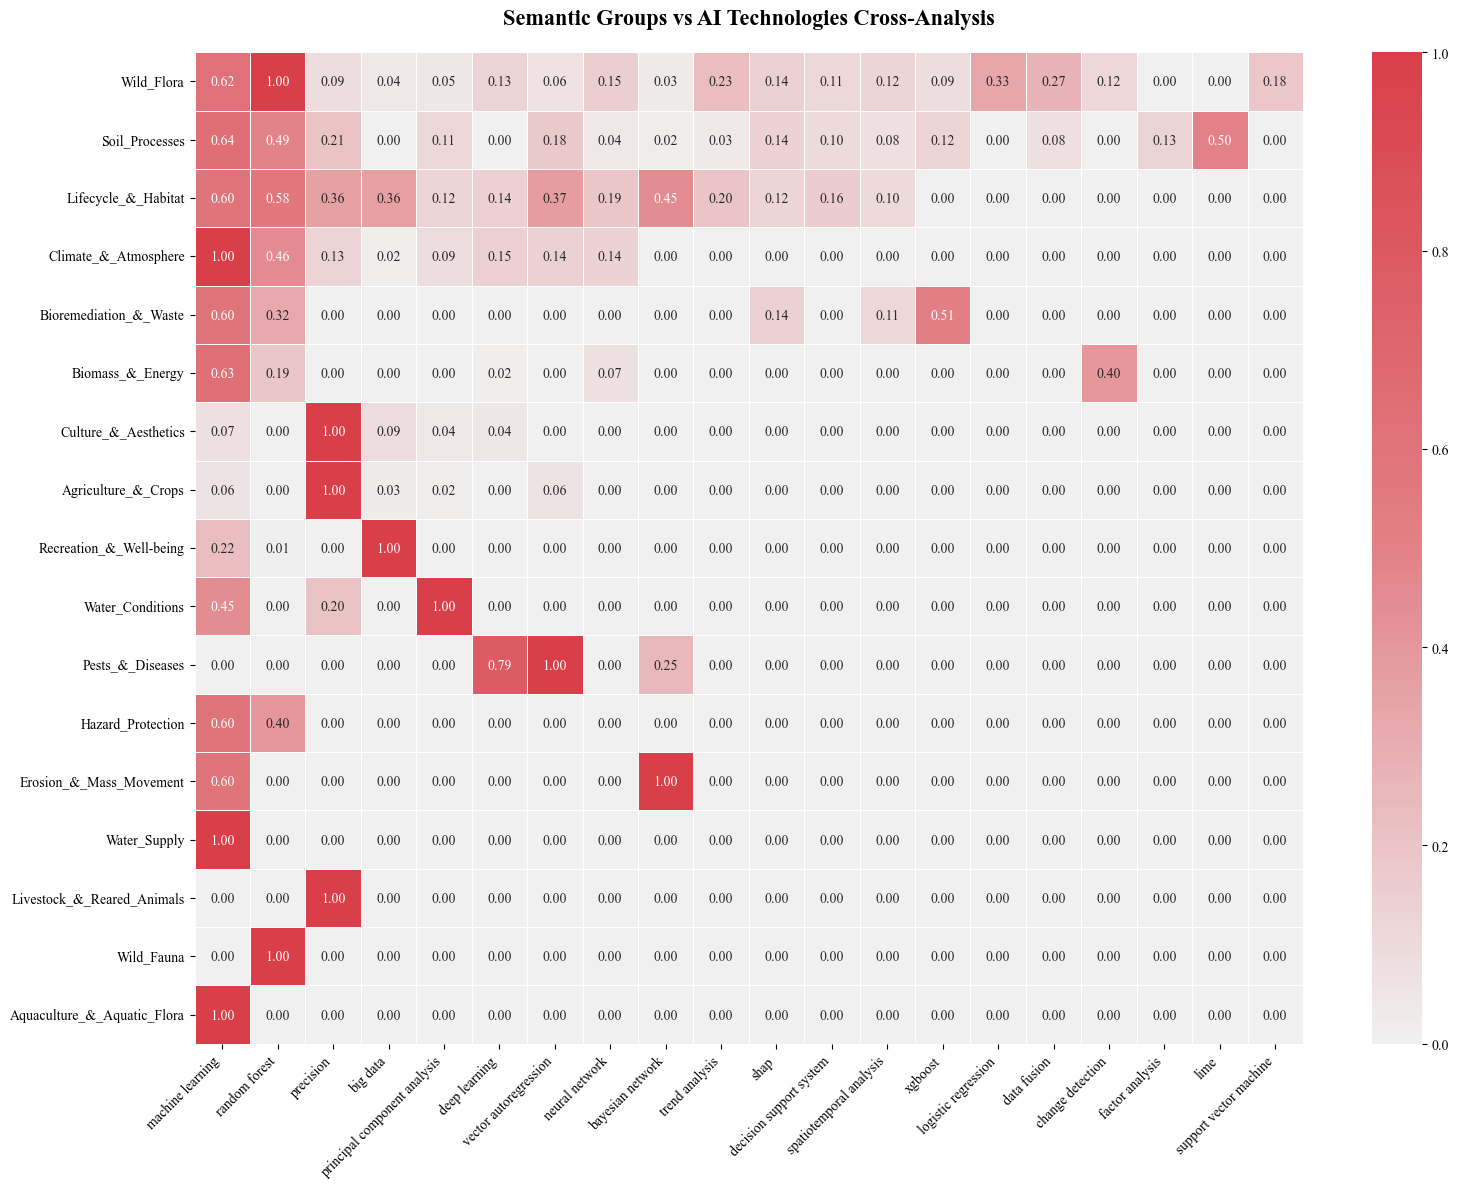

✅ Heatmap saved to: semantic_ai_heatmap_optimized.png

📑 Exporting all association results to an Excel appendix...
✅ Excel appendix successfully saved to: semantic_ai_full_associations_appendix.xlsx
   - Contains Semantic_to_AI data: 109 records
   - Contains AI_to_Semantic data: 86 records


In [4]:
import os
import re
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

class SemanticAIAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.all_articles = []
        self.articles = []

        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning", 
            "semi supervised learning", "self training", "active learning", 
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction", 
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR",
            "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation", 
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis", 
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model", 
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm", 
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR", 
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR", 
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO", 
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]

        # === 1.1 Canonical mapping: merge different spellings of the SAME AI keyword ===
        # Only variants of the same concept are mapped (e.g. "ML" -> "machine learning").
        # Every canonical form is chosen FROM the original ai_keywords list, so the
        # canonical keyword set fully covers the original vocabulary without adding
        # any new keyword. Coverage is verified in _initialize_ai_canonical_groups().
        # Note: "LDA" is intentionally NOT mapped because it is ambiguous
        # (linear discriminant analysis vs. latent dirichlet allocation).
        self.ai_keyword_canonical_map = {
            # --- learning paradigms ---
            "ml": "machine learning",
            "dl": "deep learning",
            "rl": "reinforcement learning",
            "ensemble methods": "ensemble learning",

            # --- neural network family ---
            "artificial neural network": "neural network",
            "ann": "neural network",
            "dnn": "deep neural network",
            "cnn": "convolutional neural network",
            "rnn": "recurrent neural network",
            "lstm": "long short-term memory",
            "gru": "gated recurrent unit",
            "gnn": "graph neural network",
            "gcn": "graph convolutional network",
            "resnet": "residual network",
            "vit": "vision transformer",
            "mlp": "multilayer perceptron",
            "seq2seq": "sequence-to-sequence",

            # --- transformer family ---
            "transformers": "transformer",

            # --- generative / representation learning ---
            "gan": "generative adversarial network",
            "vae": "variational autoencoder",

            # --- classical ML models ---
            "svm": "support vector machine",
            "svr": "support vector regression",
            "knn": "k-nearest neighbor",
            "gmm": "gaussian mixture model",

            # --- dimensionality reduction ---
            "pca": "principal component analysis",
            "ica": "independent component analysis",
            "svd": "singular value decomposition",
            "t-sne": "t-distributed stochastic neighbor embedding",
            "umap": "uniform manifold approximation and projection",

            # --- boosting ---
            "gbdt": "gradient boosting decision tree",

            # --- reinforcement learning ---
            "mdp": "markov decision process",
            "td learning": "temporal difference learning",
            "dqn": "deep q-network",
            "actor-critic framework": "actor-critic",
            "sarsa": "state-action-reward-state-action",
            "ppo": "proximal policy optimization",
            "ddpg": "deep deterministic policy gradient",
            "sac": "soft actor-critic",
            "marl": "multi-agent reinforcement learning",
            "maddpg": "multi-agent deep deterministic policy gradient",
            "mappo": "multi-agent proximal policy optimization",

            # --- computer vision ---
            "sift": "scale-invariant feature transform",
            "hog": "histogram of oriented gradients",
            "ocr": "optical character recognition",
            "you only look once": "yolo",

            # --- NLP ---
            "nlp": "natural language processing",
            "ner": "named entity recognition",
            "pos tagging": "part-of-speech tagging",
            "bow": "bag of words",
            "llm": "large language model",

            # --- optimization ---
            "sgd": "stochastic gradient descent",
            "adaptive moment estimation": "adam optimizer",
            "pso": "particle swarm optimization",
            "aco": "ant colony optimization",

            # --- time series ---
            "arima": "autoregressive integrated moving average",
            "sarima": "seasonal arima",
            "var": "vector autoregression",
            "dtw": "dynamic time warping",

            # --- statistics / probabilistic models ---
            "map estimation": "maximum a posteriori",
            "em algorithm": "expectation maximization",
            "mcmc": "markov chain monte carlo",
            "hmm": "hidden markov model",

            # --- model selection & evaluation ---
            "hyperparameter tuning": "hyperparameter optimization",
            "roc": "roc curve",

            # --- application-level synonyms ---
            "outlier detection": "anomaly detection",

            # --- expert / knowledge systems ---
            "rule based system": "rule-based system",
            "dss": "decision support system",
            "cbr": "case-based reasoning",

            # --- explainability & automation ---
            "xai": "explainable ai",
            "automl": "automated machine learning",
            "nas": "neural architecture search",
        }

        # === 2. Expanded fine-grained semantic groups (applying relaxed inclusion matching) ===
        self.semantic_groups = {
            'Agriculture_&_Crops': ['crops', 'cereals', 'root crops', 'soft fruit', 'fodder', 'livestock feed', 'cultivated plants', 'plantations', 'agriculture', 'farming', 'harvest', 'orchard'],
            'Aquaculture_&_Aquatic_Flora': ['aquaculture', 'in-situ aquaculture', 'cultivated aquatic plants', 'algae', 'seaweed', 'marine plants'],
            'Livestock_&_Reared_Animals': ['reared animals', 'beef', 'dairy', 'animal products', 'livestock', 'cattle', 'poultry', 'sheep', 'pigs', 'pasture'],
            'Biomass_&_Energy': ['fibres', 'materials', 'energy source', 'bioenergy', 'fibres from animals', 'mechanical energy', 'biogas', 'wild plant materials', 'wild plant energy', 'wild animal nutrition', 'wild animal materials', 'biomass', 'biofuel', 'timber', 'wood'],
            'Wild_Flora': ['wild plants', 'terrestrial plants', 'aquatic plants', 'wild fungi', 'wild algae', 'flora', 'vegetation', 'forest', 'grassland', 'wetland plants'],
            'Wild_Fauna': ['wild animals', 'terrestrial animals', 'aquatic animals', 'fauna', 'wildlife', 'birds', 'mammals', 'fishes', 'insects', 'amphibians'],
            'Water_Supply': ['surface water', 'ground water', 'drinking water', 'non-drinking water', 'water supply', 'freshwater', 'reservoir', 'aquifer'],
            'Genetics_&_Breeding': ['seeds', 'spores', 'plant materials for breeding', 'new strains', 'varieties', 'individual genes', 'biological entities', 'animal genetic material', 'genetics', 'breeding', 'genomics', 'dna'],
            'Bioremediation_&_Waste': ['bio-remediation', 'micro-organisms', 'pollution degradation', 'filtration', 'sequestration', 'storage', 'accumulation', 'waste mediation', 'toxic substances', 'bioremediation', 'phytoremediation', 'waste treatment', 'water purification', 'pollution control'],
            'Sensory_Regulation': ['smell reduction', 'noise attenuation', 'visual screening', 'odor control', 'soundscape', 'acoustic regulation'],
            'Erosion_&_Mass_Movement': ['erosion control', 'water erosion', 'wind erosion', 'mass movement', 'landslides', 'erosion', 'soil erosion', 'coastal erosion', 'avalanche'],
            'Hydrology_&_Flow': ['hydrological cycle', 'water flow regulation', 'runoff', 'base flows', 'peak flows', 'hydrology', 'streamflow', 'flood control', 'drainage'],
            'Hazard_Protection': ['hazard mitigation', 'flood mitigation', 'surge protection', 'wind protection', 'fire protection', 'disaster risk reduction', 'storm surge', 'fire', 'wildfire'],
            'Lifecycle_&_Habitat': ['pollination', 'gamete dispersal', 'seed dispersal', 'nursery populations', 'breeding grounds', 'gene pool protection', 'genetic diversity conservation', 'population establishment', 'refuge habitats', 'feeding grounds', 'habitat', 'biodiversity', 'pollinators'],
            'Pests_&_Diseases': ['pest control', 'invasive species management', 'disease control', 'pest', 'disease', 'invasive species', 'biological control', 'pathogens'],
            'Soil_Processes': ['soil quality', 'weathering processes', 'decomposition', 'fixing processes', 'soil structure', 'biological agents', 'soil porosity', 'role of bacteria', 'role of fungi', 'soil', 'soil formation', 'nutrient cycling'],
            'Water_Conditions': ['water conditions', 'chemical condition', 'macronutrients', 'freshwater regulation', 'saltwater regulation', 'water quality', 'eutrophication'],
            'Climate_&_Atmosphere': ['atmospheric composition', 'oceanic circulation', 'climate change regulation', 'temperature regulation', 'humidity', 'ventilation', 'transpiration', 'microclimate', 'climate change', 'climate regulation', 'carbon sink', 'greenhouse gas'],
            'Recreation_&_Well-being': ['recreational activities', 'health promotion', 'recuperation', 'enjoyment', 'active interactions', 'immersive interactions', 'passive interactions', 'observational interactions', 'recreation', 'ecotourism', 'tourism', 'mental health', 'physical health'],
            'Knowledge_&_Education': ['scientific investigation', 'traditional ecological knowledge', 'education', 'training', 'environmental education', 'scientific research', 'indigenous knowledge'],
            'Culture_&_Aesthetics': ['culture', 'heritage', 'cultural resonance', 'aesthetic experiences', 'entertainment', 'representation outside setting', 'cultural heritage', 'landscape aesthetics', 'cultural identity'],
            'Spiritual_&_Symbolic': ['symbolic meaning', 'sense of place', 'distinctiveness', 'spiritual meaning', 'religious meaning', 'sacred landscapes', 'spiritual', 'religious', 'sacred groves'],
            'Conservation_&_Existence': ['contemporary existence', 'conservation importance', 'inter-generational existence', 'bequest value', 'intrinsic value of biodiversity', 'existence value', 'wildlife conservation']
        }
        
        self._initialize_semantic_groups()
        self._initialize_ai_canonical_groups()
        
    def _initialize_semantic_groups(self):
        """Flatten to obtain the base vocabulary collection"""
        self.all_cices_keywords = []
        for keywords_list in self.semantic_groups.values():
            self.all_cices_keywords.extend([kw.lower() for kw in keywords_list])
        self.all_cices_keywords = list(set(self.all_cices_keywords))


    def _initialize_ai_canonical_groups(self):
        """Group different spellings of the same AI keyword under one canonical form,
        and verify that the canonical keyword set fully covers the original vocabulary
        (no omissions and no new keywords)."""
        original_forms = {kw.lower() for kw in self.ai_keywords}

        self.ai_canonical_groups = defaultdict(list)
        for kw in self.ai_keywords:
            canon = self.ai_keyword_canonical_map.get(kw.lower(), kw.lower())
            self.ai_canonical_groups[canon].append(kw.lower())

        self.canonical_ai_keywords = sorted(self.ai_canonical_groups.keys())

        # Every original spelling must be covered by some canonical group
        # (no omissions), and every canonical form must come from the original
        # vocabulary (no new keywords).
        covered_spellings = {s for spellings in self.ai_canonical_groups.values() for s in spellings}
        missing = original_forms - covered_spellings
        extra = set(self.canonical_ai_keywords) - original_forms
        if missing:
            raise ValueError(f"Canonical mapping incomplete, missing keywords: {sorted(missing)}")
        if extra:
            raise ValueError(f"Canonical mapping introduces new keywords: {sorted(extra)}")

    def is_cices_match(self, article_keyword, cices_keyword):
        """
        [Relaxed matching logic] Substring inclusion matching (Substring Matching)
        """
        article_kw = article_keyword.lower().strip()
        cices_kw = cices_keyword.lower().strip()
        return cices_kw in article_kw

    def is_ai_match(self, search_text, ai_keyword):
        """
        [Keeps strict matching logic] Rigorous word boundary validation (Strict Word Boundary)
        """
        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()
        
        if search_text == ai_kw:
            return True
        
        strict_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr", 
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr", 
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo", 
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]
        
        if ai_kw in strict_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))
        
        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))
        
        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))

    def generate_article_hash(self, article):
        parts = []
        if article.get('title'):
            parts.append(article['title'].lower().strip())
        if article.get('year'):
            parts.append(article['year'])
        if article.get('authors'):
            parts.append(article['authors'][0].lower().strip())
        return hashlib.md5('||'.join(parts).encode()).hexdigest()

    def read_literature_files(self):
        files = [f for f in os.listdir(self.data_directory) 
                if f.endswith('.txt') and 'download' in f]
        
        for file in sorted(files):
            try:
                with open(os.path.join(self.data_directory, file), 'r', 
                         encoding='utf-8', errors='ignore') as f:
                    self.parse_articles(f.read(), file)
            except Exception as e:
                print(f"⚠️ Failed to read {file}: {e}")

    def parse_articles(self, content, filename):
        for article_text in re.split(r'\nER\s*\n', content):
            if not article_text.strip():
                continue
            
            article = {
                'filename': filename,
                'keywords': set(),
                'keywords_plus': set(),
                'title': '',
                'year': '',
                'authors': []
            }
            
            for pattern, field in [
                (r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', 'keywords_plus'),
                (r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', 'keywords')
            ]:
                match = re.search(pattern, article_text, re.DOTALL)
                if match:
                    keywords = self.extract_keywords(match.group(1))
                    article[field].update(keywords)
            
            ti_match = re.search(r'\nTI\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if ti_match:
                article['title'] = ti_match.group(1).replace('\n', ' ').strip()
            py_match = re.search(r'\nPY\s+(\d{4})', article_text)
            if py_match:
                article['year'] = py_match.group(1)
            else:
                ea_match = re.search(r'\nEA\s+.*?(\d{4})', article_text)
                if ea_match:
                    article['year'] = ea_match.group(1)
                else:
                    pd_match = re.search(r'\nPD\s+.*?(\d{4})', article_text)
                    if pd_match:
                        article['year'] = pd_match.group(1)
            
            au_match = re.search(r'\nAU\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if au_match:
                article['authors'] = [a.strip() for a in au_match.group(1).split('\n') if a.strip()]
            
            if article['keywords'] or article['keywords_plus']:
                article['all_keywords'] = article['keywords'] | article['keywords_plus']
                self.articles.append(article)

    def extract_keywords(self, text):
        keywords = []
        for kw in re.split(r'[;\n]', text.replace('\n', ' ')):
            kw = re.sub(r'\s+', ' ', kw.strip().lower())
            kw = kw.strip('.,;()[]{}"\'-')
            if kw and len(kw) > 2:
                keywords.append(kw)
        return keywords

    def identify_semantic_ai_articles(self):
        """Identify combined articles (applying the high-recall relaxed matching strategy)"""
        combo_articles = []
        
        for article in self.articles:
            matched_semantic_groups = set()
            
            for group_name, group_keywords in self.semantic_groups.items():
                group_matched = False
                for kw in group_keywords:
                    for article_keyword in article['all_keywords']:
                        if self.is_cices_match(article_keyword, kw):
                            group_matched = True
                            break
                    if group_matched:
                        break 
                
                if group_matched:
                    matched_semantic_groups.add(group_name)
            
            matched_ai = []
            keywords_text = ' '.join(article['all_keywords'])
            # Match any spelling of a canonical group, then record ONLY the canonical keyword.
            for canon_kw, spellings in self.ai_canonical_groups.items():
                if any(self.is_ai_match(keywords_text, spelling) for spelling in spellings):
                    matched_ai.append(canon_kw)
            
            if matched_semantic_groups and matched_ai:
                article['matched_semantic_groups'] = list(matched_semantic_groups)
                article['matched_ai'] = matched_ai
                article['article_hash'] = self.generate_article_hash(article)
                combo_articles.append(article)

        unique_articles = []
        seen_hashes = set()
        for article in combo_articles:
            if article['article_hash'] not in seen_hashes:
                seen_hashes.add(article['article_hash'])
                unique_articles.append(article)

        return unique_articles

    def analyze_combinations(self, combo_articles):
        """Count co-occurrence relationships"""
        cooccurrence = defaultdict(lambda: defaultdict(int))
        all_semantic_counts = Counter()
        all_ai_counts = Counter()
        combo_semantic_counts = Counter()
        combo_ai_counts = Counter()
        
        for article in self.articles:
            matched_groups = set()
            for group_name, group_keywords in self.semantic_groups.items():
                group_matched = False
                for kw in group_keywords:
                    for article_keyword in article['all_keywords']:
                        if self.is_cices_match(article_keyword, kw):
                            group_matched = True
                            break
                    if group_matched:
                        break
                if group_matched:
                    matched_groups.add(group_name)
            
            for group in matched_groups:
                all_semantic_counts[group] += 1
            
            keywords_text = ' '.join(article['all_keywords'])
            matched_ai = set()
            # Match any spelling of a canonical group, then count ONLY the canonical keyword.
            for canon_kw, spellings in self.ai_canonical_groups.items():
                if any(self.is_ai_match(keywords_text, spelling) for spelling in spellings):
                    matched_ai.add(canon_kw)
            for ai_kw in matched_ai:
                all_ai_counts[ai_kw] += 1
        
        for article in combo_articles:
            for group in article['matched_semantic_groups']:
                combo_semantic_counts[group] += 1
                for ai_kw in set(article['matched_ai']):
                    cooccurrence[group][ai_kw] += 1
            for ai_kw in set(article['matched_ai']):
                combo_ai_counts[ai_kw] += 1
        
        return cooccurrence, all_semantic_counts, all_ai_counts, combo_semantic_counts, combo_ai_counts

    def calculate_association_metrics(self, cooccurrence, all_sem_cnt, all_ai_cnt, 
                                     combo_sem_cnt, combo_ai_cnt, total_combo, total_arts, min_cooc=2):
        print(f"📊 Calculating association metrics (co-occurrence ≥ {min_cooc}, lift ≥ 1.0)")
        
        semantic_to_ai_results = []
        for sem_group in combo_sem_cnt:
            ai_combinations = []
            for ai_kw, cooccur_count in cooccurrence[sem_group].items():
                if cooccur_count >= min_cooc:
                    support = cooccur_count / total_combo
                    confidence = cooccur_count / combo_sem_cnt[sem_group]
                    ai_prob = all_ai_cnt[ai_kw] / total_arts
                    lift = confidence / ai_prob if ai_prob > 0 else 0
                    
                    if lift >= 1.0:
                        ai_combinations.append({
                            'AI_Keyword': ai_kw, 'Cooccurrence': cooccur_count,
                            'Confidence': round(confidence, 4), 'Lift': round(lift, 4), 'Support': round(support, 4)
                        })
            
            if ai_combinations:
                semantic_to_ai_results.append({
                    'Semantic_Group': sem_group,
                    'Keywords_Count': len(self.semantic_groups[sem_group]),
                    'Group_Freq_Combo': combo_sem_cnt[sem_group],
                    'Group_Freq_All': all_sem_cnt[sem_group],
                    'AI_Combinations': sorted(ai_combinations, key=lambda x: x['Cooccurrence'], reverse=True)
                })
        
        ai_to_semantic_results = []
        for ai_kw in combo_ai_cnt:
            sem_combinations = []
            for sem_group in combo_sem_cnt:
                cooccur_count = cooccurrence[sem_group][ai_kw]
                if cooccur_count >= min_cooc:
                    support = cooccur_count / total_combo
                    confidence = cooccur_count / combo_ai_cnt[ai_kw]
                    sem_prob = all_sem_cnt[sem_group] / total_arts
                    lift = confidence / sem_prob if sem_prob > 0 else 0
                    
                    if lift >= 1.0:
                        sem_combinations.append({
                            'Semantic_Group': sem_group, 'Cooccurrence': cooccur_count,
                            'Confidence': round(confidence, 4), 'Lift': round(lift, 4), 'Support': round(support, 4)
                        })
            
            if sem_combinations:
                ai_to_semantic_results.append({
                    'AI_Keyword': ai_kw, 'AI_Freq_Combo': combo_ai_cnt[ai_kw], 'AI_Freq_All': all_ai_cnt[ai_kw],
                    'Semantic_Combinations': sorted(sem_combinations, key=lambda x: x['Cooccurrence'], reverse=True)
                })
        
        return semantic_to_ai_results, ai_to_semantic_results

    def _score_associations(self, associations):
        if not associations: return []
        
        confidences = [a['Confidence'] for a in associations]
        lifts = [a['Lift'] for a in associations]
        cooccurrences = [a['Cooccurrence'] for a in associations]
        
        def normalize(values):
            if len(values) <= 1 or max(values) == min(values): return [1.0] * len(values)
            return [(v - min(values)) / (max(values) - min(values)) for v in values]
        
        norm_conf, norm_lift, norm_cooc = normalize(confidences), normalize(lifts), normalize(cooccurrences)
        
        scored_associations = []
        for i, assoc in enumerate(associations):
            score = 0.4 * norm_conf[i] + 0.4 * norm_lift[i] + 0.2 * norm_cooc[i]
            scored_assoc = assoc.copy()
            scored_assoc['Composite_Score'] = round(score, 4)
            scored_associations.append(scored_assoc)
        
        scored_associations.sort(key=lambda x: x['Composite_Score'], reverse=True)
        return scored_associations

    def generate_detailed_report(self, sem_to_ai, ai_to_sem, combo_arts):
        print("\n" + "="*80)
        print("Interdisciplinary In-depth Cross Analysis: Domain Semantic Groups → AI Technologies")
        print("="*80)
        
        print(f"\n📌 I. Semantic Group → AI Association Analysis (Global Top 30)")
        print("-" * 80)
        all_sem_assocs = []
        for res in sem_to_ai:
            for assoc in res['AI_Combinations']:
                copy_assoc = assoc.copy()
                copy_assoc['Semantic_Group'] = res['Semantic_Group']
                all_sem_assocs.append(copy_assoc)
        
        all_sem_assocs.sort(key=lambda x: x.get('Composite_Score', 0), reverse=True)
        print(f"{'Rank':<4} {'Semantic Group':<30} {'AI Technology':<25} {'Composite Score':<8} {'Co-occ':<6}")
        print("-" * 80)
        for i, a in enumerate(all_sem_assocs[:30], 1):
            print(f"{i:<4} {a['Semantic_Group'][:28]:<30} {a['AI_Keyword'][:23]:<25} {a.get('Composite_Score',0):<8.3f} {a['Cooccurrence']:<6}")

        print(f"\n📌 II. AI → Semantic Group Association Analysis (Global Top 30)")
        print("-" * 80)
        all_ai_assocs = []
        for res in ai_to_sem:
            for assoc in res['Semantic_Combinations']:
                copy_assoc = assoc.copy()
                copy_assoc['AI_Keyword'] = res['AI_Keyword']
                all_ai_assocs.append(copy_assoc)
                
        all_ai_assocs.sort(key=lambda x: x.get('Composite_Score', 0), reverse=True)
        print(f"{'Rank':<4} {'AI Technology':<25} {'Semantic Group':<30} {'Composite Score':<8} {'Co-occ':<6}")
        print("-" * 80)
        for i, a in enumerate(all_ai_assocs[:30], 1):
            print(f"{i:<4} {a['AI_Keyword'][:23]:<25} {a['Semantic_Group'][:28]:<30} {a.get('Composite_Score',0):<8.3f} {a['Cooccurrence']:<6}")

    def plot_heatmap(self, sem_to_ai, ai_to_sem, top_n=20):
        print("\n" + "="*80)
        print("📈 Plotting semantic group - AI association heatmap...")
        print("="*80)
        
        semantic_freq = defaultdict(int)
        ai_freq = defaultdict(int)
        
        for r in sem_to_ai:
            for a in r['AI_Combinations']:
                semantic_freq[r['Semantic_Group']] += a['Cooccurrence']
                ai_freq[a['AI_Keyword']] += a['Cooccurrence']
                
        top_semantic = [k for k, v in sorted(semantic_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]]
        top_ai = [k for k, v in sorted(ai_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]]
        
        if not top_semantic or not top_ai: return None
        
        heatmap_data = np.zeros((len(top_semantic), len(top_ai)))
        
        for r in sem_to_ai:
            if r['Semantic_Group'] in top_semantic:
                row_idx = top_semantic.index(r['Semantic_Group'])
                for a in r['AI_Combinations']:
                    if a['AI_Keyword'] in top_ai:
                        heatmap_data[row_idx, top_ai.index(a['AI_Keyword'])] = a.get('Composite_Score', 0)
                        
        heatmap_df = pd.DataFrame(heatmap_data, index=top_semantic, columns=top_ai)
        
        plt.figure(figsize=(16, 12))
        cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#f0f0f0', '#E28187', '#D93F49'])
        ax = sns.heatmap(heatmap_df, cmap=cmap, annot=True, fmt='.2f', linewidths=0.5, linecolor='white')
        
        plt.title('Semantic Groups vs AI Technologies Cross-Analysis', fontsize=16, fontweight='bold', pad=20)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
        plt.tight_layout()
        plt.savefig('semantic_ai_heatmap_optimized.png', dpi=600, bbox_inches='tight')
        plt.show()
        print("✅ Heatmap saved to: semantic_ai_heatmap_optimized.png")

    def export_all_associations_to_excel(self, sem_to_ai, ai_to_sem, output_filename="semantic_ai_full_associations_appendix.xlsx"):
        """Export the results of all association analyses to an Excel file as a research appendix"""
        print("\n" + "="*80)
        print("📑 Exporting all association results to an Excel appendix...")
        print("="*80)
        
        # 1. Flatten the Semantic -> AI data
        sem_ai_data = []
        for res in sem_to_ai:
            sem_group = res['Semantic_Group']
            for assoc in res['AI_Combinations']:
                sem_ai_data.append({
                    'Semantic_Group': sem_group,
                    'AI_Keyword': assoc['AI_Keyword'],
                    'Cooccurrence': assoc['Cooccurrence'],
                    'Support': assoc.get('Support', 0),
                    'Confidence': assoc.get('Confidence', 0),
                    'Lift': assoc.get('Lift', 0),
                    'Composite_Score': assoc.get('Composite_Score', 0)
                })
        
        df_sem_ai = pd.DataFrame(sem_ai_data)
        if not df_sem_ai.empty:
            df_sem_ai = df_sem_ai.sort_values(by=['Semantic_Group', 'Composite_Score'], ascending=[True, False])

        ai_sem_data = []
        for res in ai_to_sem:
            ai_kw = res['AI_Keyword']
            for assoc in res['Semantic_Combinations']:
                ai_sem_data.append({
                    'AI_Keyword': ai_kw,
                    'Semantic_Group': assoc['Semantic_Group'],
                    'Cooccurrence': assoc['Cooccurrence'],
                    'Support': assoc.get('Support', 0),
                    'Confidence': assoc.get('Confidence', 0),
                    'Lift': assoc.get('Lift', 0),
                    'Composite_Score': assoc.get('Composite_Score', 0)
                })
                
        df_ai_sem = pd.DataFrame(ai_sem_data)
        if not df_ai_sem.empty:
            df_ai_sem = df_ai_sem.sort_values(by=['AI_Keyword', 'Composite_Score'], ascending=[True, False])

        try:
            with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
                if not df_sem_ai.empty:
                    df_sem_ai.to_excel(writer, sheet_name='Semantic_to_AI_Full', index=False)
                if not df_ai_sem.empty:
                    df_ai_sem.to_excel(writer, sheet_name='AI_to_Semantic_Full', index=False)
            print(f"✅ Excel appendix successfully saved to: {output_filename}")
            print(f"   - Contains Semantic_to_AI data: {len(df_sem_ai)} records")
            print(f"   - Contains AI_to_Semantic data: {len(df_ai_sem)} records")
        except Exception as e:
            print(f"⚠️ Error saving Excel: {e}")

    def run_analysis(self, min_cooccurrence=2):
        print("🚀 Starting execution: Advanced cross-analysis engine (high-recall substring matching version)...")

        self.read_literature_files()
        if not self.articles: return

        combo_articles = self.identify_semantic_ai_articles()
        if not combo_articles: return

        cooc, all_sem, all_ai, combo_sem, combo_ai = self.analyze_combinations(combo_articles)

        sem_to_ai, ai_to_sem = self.calculate_association_metrics(
            cooc, all_sem, all_ai, combo_sem, combo_ai, len(combo_articles), len(self.articles), min_cooccurrence)
        
        for res in sem_to_ai: res['AI_Combinations'] = self._score_associations(res['AI_Combinations'])
        for res in ai_to_sem: res['Semantic_Combinations'] = self._score_associations(res['Semantic_Combinations'])

        self.generate_detailed_report(sem_to_ai, ai_to_sem, combo_articles)

        self.plot_heatmap(sem_to_ai, ai_to_sem, top_n=20)

        self.export_all_associations_to_excel(sem_to_ai, ai_to_sem)

if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = SemanticAIAnalyzer(data_directory=TARGET_DIR)
    analyzer.run_analysis(min_cooccurrence=3)

In [6]:
import pandas as pd
import re

def clean_bibliometric_country_data(input_file, output_file):
    print(f"🚀 Starting to clean data file: {input_file}")

    df = pd.read_excel(input_file)

    valid_countries = {
        'AFGHANISTAN', 'ALBANIA', 'ALGERIA', 'ANDORRA', 'ANGOLA', 'ANTIGUA AND BARBUDA',
        'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN',
        'BANGLADESH', 'BARBADOS', 'BELARUS', 'BELGIUM', 'BELIZE', 'BENIN', 'BHUTAN',
        'BOLIVIA', 'BOSNIA AND HERZEGOVINA', 'BOTSWANA', 'BRAZIL', 'BRUNEI', 'BULGARIA',
        'BURKINA FASO', 'BURUNDI', 'CAMBODIA', 'CAMEROON', 'CANADA', 'CAPE VERDE',
        'CENTRAL AFRICAN REPUBLIC', 'CHAD', 'CHILE', 'CHINA', 'COLOMBIA', 'COMOROS',
        'CONGO', 'COSTA RICA', 'CROATIA', 'CUBA', 'CYPRUS', 'CZECH REPUBLIC',
        'DENMARK', 'DJIBOUTI', 'DOMINICA', 'DOMINICAN REPUBLIC', 'EAST TIMOR',
        'ECUADOR', 'EGYPT', 'EL SALVADOR', 'EQUATORIAL GUINEA', 'ERITREA', 'ESTONIA',
        'ETHIOPIA', 'FIJI', 'FINLAND', 'FRANCE', 'GABON', 'GAMBIA', 'GEORGIA',
        'GERMANY', 'GHANA', 'GREECE', 'GRENADA', 'GUATEMALA', 'GUINEA', 'GUINEA-BISSAU',
        'GUYANA', 'HAITI', 'HONDURAS', 'HUNGARY', 'ICELAND', 'INDIA', 'INDONESIA',
        'IRAN', 'IRAQ', 'IRELAND', 'ISRAEL', 'ITALY', 'JAMAICA', 'JAPAN', 'JORDAN',
        'KAZAKHSTAN', 'KENYA', 'KIRIBATI', 'KUWAIT', 'KYRGYZSTAN', 'LAOS', 'LATVIA',
        'LEBANON', 'LESOTHO', 'LIBERIA', 'LIBYA', 'LIECHTENSTEIN', 'LITHUANIA',
        'LUXEMBOURG', 'MACEDONIA', 'MADAGASCAR', 'MALAWI', 'MALAYSIA', 'MALDIVES',
        'MALI', 'MALTA', 'MARSHALL ISLANDS', 'MAURITANIA', 'MAURITIUS', 'MEXICO',
        'MICRONESIA', 'MOLDOVA', 'MONACO', 'MONGOLIA', 'MONTENEGRO', 'MOROCCO',
        'MOZAMBIQUE', 'MYANMAR', 'NAMIBIA', 'NAURU', 'NEPAL', 'NETHERLANDS',
        'NEW ZEALAND', 'NICARAGUA', 'NIGER', 'NIGERIA', 'NORTH KOREA', 'NORWAY',
        'OMAN', 'PAKISTAN', 'PALAU', 'PANAMA', 'PAPUA NEW GUINEA', 'PARAGUAY',
        'PERU', 'PHILIPPINES', 'POLAND', 'PORTUGAL', 'QATAR', 'ROMANIA', 'RUSSIA',
        'RWANDA', 'SAINT KITTS AND NEVIS', 'SAINT LUCIA', 'SAINT VINCENT AND THE GRENADINES',
        'SAMOA', 'SAN MARINO', 'SAO TOME AND PRINCIPE', 'SAUDI ARABIA', 'SENEGAL',
        'SERBIA', 'SEYCHELLES', 'SIERRA LEONE', 'SINGAPORE', 'SLOVAKIA', 'SLOVENIA',
        'SOLOMON ISLANDS', 'SOMALIA', 'SOUTH AFRICA', 'SOUTH KOREA', 'SOUTH SUDAN',
        'SPAIN', 'SRI LANKA', 'SUDAN', 'SURINAME', 'SWAZILAND', 'SWEDEN', 'SWITZERLAND',
        'SYRIA', 'TAJIKISTAN', 'TANZANIA', 'THAILAND', 'TOGO', 'TONGA', 'TRINIDAD AND TOBAGO',
        'TUNISIA', 'TURKEY', 'TURKMENISTAN', 'TUVALU', 'UGANDA', 'UK', 'UKRAINE',
        'UAE', 'URUGUAY', 'USA', 'UZBEKISTAN', 'VANUATU', 'VATICAN CITY', 'VENEZUELA',
        'VIETNAM', 'YEMEN', 'ZAMBIA', 'ZIMBABWE', 'GREENLAND', 'PUERTO RICO', 'HONG KONG',
        'MACAU', 'BERMUDA', 'GUAM', 'DEMOCRATIC REPUBLIC OF THE CONGO', 'IVORY COAST'
    }

    country_mapping = {
        'VIET NAM': 'Vietnam',
        'CZECHIA': 'Czech Republic',
        'CZECHOSLOVAKIA': 'Czech Republic',
        'BOSNIA HERCEG': 'Bosnia and Herzegovina',
        'DOMINICAN REP': 'Dominican Republic',
        'DEM REP CONGO': 'Democratic Republic of the Congo',
        'DR CONGO': 'Democratic Republic of the Congo',
        'REP CONGO': 'Congo',
        'PAPUA N GUINEA': 'Papua New Guinea',
        'COTE IVOIRE': 'Ivory Coast',
        'COTE D IVOIRE': 'Ivory Coast',
        'FRENCH GUIANA': 'France',
        'TURKIYE': 'Turkey'
    }
    
    def standardize_country(raw_country):
        if not isinstance(raw_country, str):
            return None

        clean_country = re.sub(r'[^A-Za-z\s]', '', raw_country).strip().upper()

        if not clean_country or (len(clean_country) < 3 and clean_country not in ['UK', 'US']):
            return None
            
        standard_country = None

        if "USA" in clean_country or "UNITED STATES" in clean_country or "U S A" in clean_country:
            standard_country = "USA"
        elif "CHINA" in clean_country or "PEOPLES R" in clean_country or "TAIWAN" in clean_country:
            standard_country = "China" 
        elif any(x in clean_country for x in ["ENGLAND", "SCOTLAND", "WALES", "NORTH IRELAND", "NORTHERN IRELAND", "UNITED KINGDOM", "UK"]):
            standard_country = "UK"
        elif "RUSSIA" in clean_country:
            standard_country = "Russia"
        elif ("KOREA" in clean_country and "SOUTH" in clean_country) or "REPUBLIC OF KOREA" in clean_country:
            standard_country = "South Korea"
        elif "EMIRATES" in clean_country or "UAE" in clean_country:
            standard_country = "UAE"

        elif clean_country in country_mapping:
            standard_country = country_mapping[clean_country]

        elif clean_country in valid_countries:
            standard_country = clean_country.title() 
            
        return standard_country

    df['Standard_Country'] = df['Country'].apply(standardize_country)

    initial_rows = len(df)
    df_valid = df.dropna(subset=['Standard_Country'])
    filtered_rows = len(df_valid)
    
    print(f"🧹 Data filtering: {initial_rows} original entries -> {filtered_rows} valid entries after cleaning")

    numeric_cols = ['Total_Articles', 'Provisioning', 'Regulating', 'Cultural', 'AI_Methods', 'Total_Citations']
    df_grouped = df_valid.groupby('Standard_Country')[numeric_cols].sum().reset_index()

    df_grouped = df_grouped.sort_values(by='Total_Articles', ascending=False)

    df_grouped.rename(columns={'Standard_Country': 'Country'}, inplace=True)

    df_grouped.to_excel(output_file, index=False)
    
    print(f"✅ Merge and cleaning completed! Obtained {len(df_grouped)} valid standardized countries in total.")
    print(f"📁 Results have been safely saved to: {output_file}")
    print("\n🏆 Overview of the Top 10 countries by global publication count after cleaning:")
    print(df_grouped.head(10).to_string(index=False))

if __name__ == "__main__":
    input_excel = "global_country_bibliometric_stats.xlsx"
    output_excel = "global_country_bibliometric_stats_cleaned.xlsx"
    
    clean_bibliometric_country_data(input_excel, output_excel)

🚀 Starting to clean data file: global_country_bibliometric_stats.xlsx
🧹 Data filtering: 1596 original entries -> 183 valid entries after cleaning
✅ Merge and cleaning completed! Obtained 172 valid standardized countries in total.
📁 Results have been safely saved to: global_country_bibliometric_stats_cleaned.xlsx

🏆 Overview of the Top 10 countries by global publication count after cleaning:
  Country  Total_Articles  Provisioning  Regulating  Cultural  AI_Methods  Total_Citations
    China            8174           761        6870       543        1398           207465
      USA            7394           854        5868       672        1154           251299
       UK            3084           412        2247       425         403           126970
  Germany            2628           290        2055       283         343           100665
Australia            2370           322        1779       269         300            99139
   Canada            1966           283        1538       14


Starting to create the CICES ecosystem services literature graded world map...

CICES Ecosystem Services Literature Data Summary (all 196+ countries/regions)
Rank Country/Region       CICES Articles CICES Citations
--------------------------------------------------------------------------------
1    China                8174         207465         
2    USA                  7394         251299         
3    UK                   3084         126970         
4    Germany              2628         100665         
5    Australia            2370         99139          
6    Canada               1966         68819          
7    Spain                1938         64441          
8    France               1814         68344          
9    Italy                1681         58355          
10   Brazil               1453         37829          
11   Netherlands          1206         58580          
12   India                1103         24561          
13   Sweden               963          4825

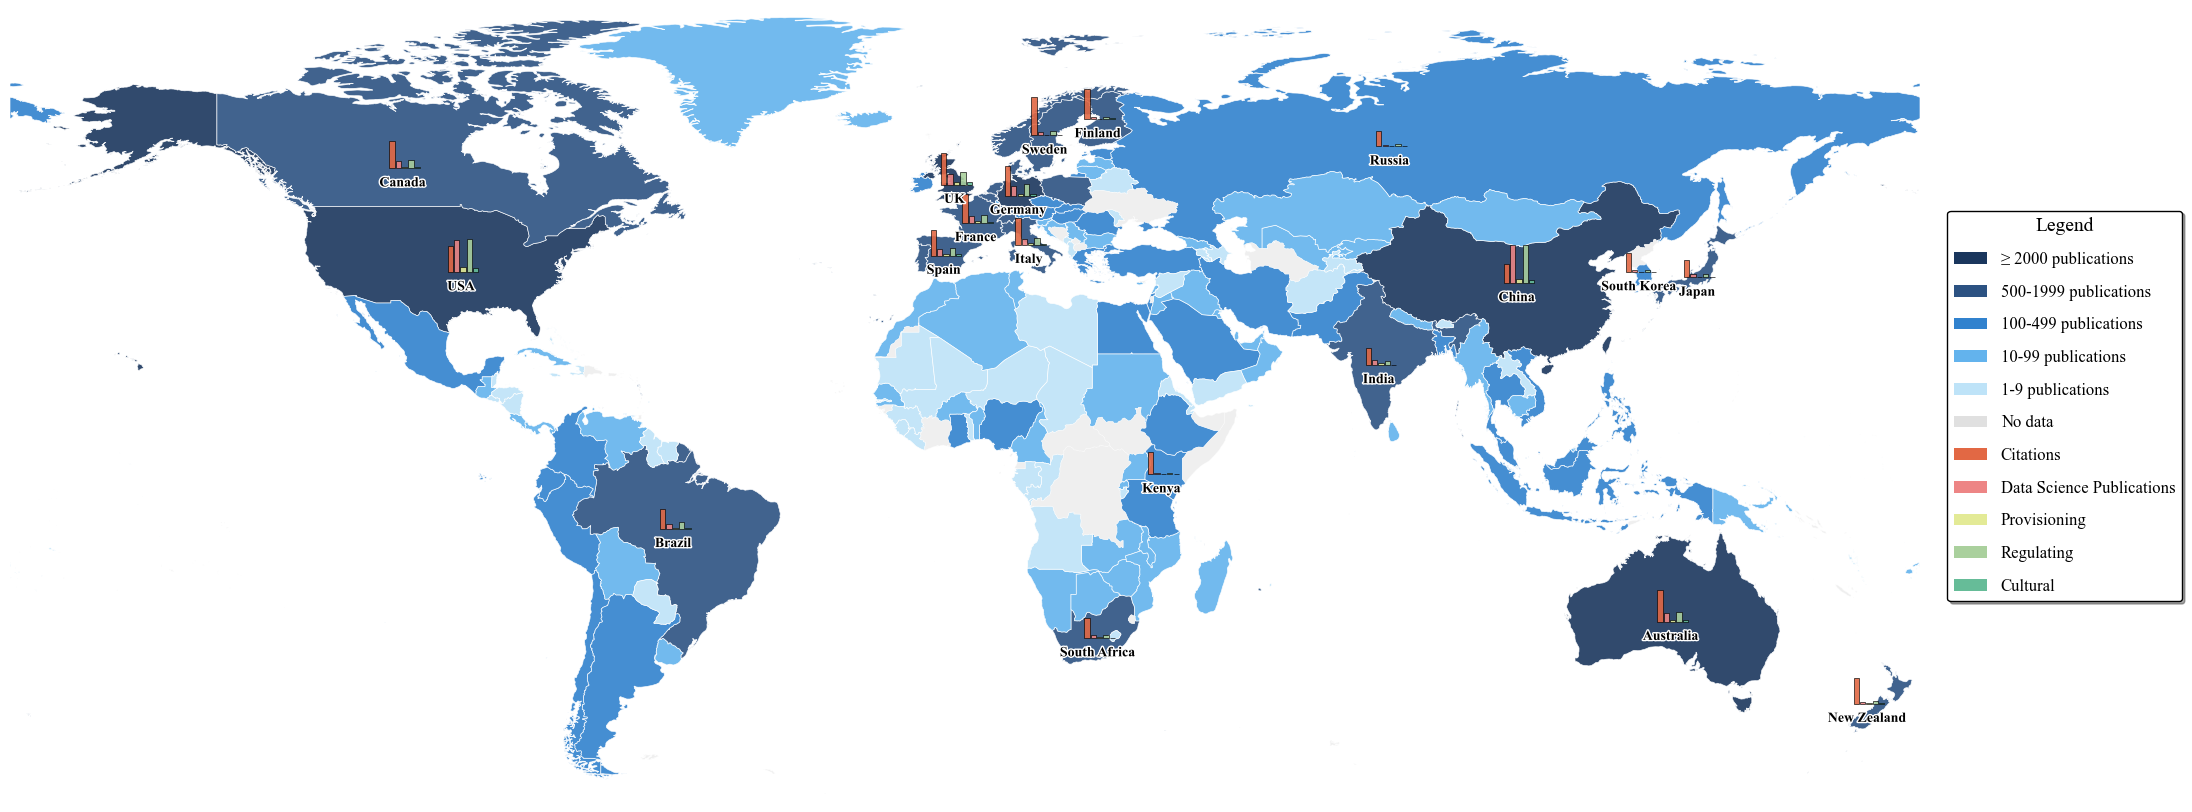


Map creation completed!
--------------------------------------------------------------------------------
Generated files:
- cices_publications_map_with_bars.png (CICES publication count graded map, DPI=600)



地图创建完成！
--------------------------------------------------------------------------------
生成的文件：
- cices_publications_map_with_bars.png (CICES发文量分级地图，DPI=600)


In [10]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.patheffects as mpatheffects
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Times New Roman', 'serif']
plt.rcParams['axes.unicode_minus'] = False


class CICESWorldMap:
    def __init__(self, data_file="global_country_bibliometric_stats_cleaned.xlsx"):
        if not os.path.exists(data_file):
            raise FileNotFoundError(f"Data file {data_file} not found, please make sure the path is correct!")
            
        self.df_source = pd.read_excel(data_file)

        self.all_countries_cices = []
        for _, row in self.df_source.iterrows():
            self.all_countries_cices.append([row['Country'], row['Total_Articles'], row['Total_Citations']])

        self.detailed_countries_data = {}
        for _, row in self.df_source.iterrows():
            self.detailed_countries_data[row['Country']] = {
                'cices_citations': row['Total_Citations'],
                'ai_articles': row['AI_Methods'],
                'provision': row['Provisioning'],
                'regulating': row['Regulating'],
                'cultural': row['Cultural']
            }

        self.country_name_mapping = {
            'USA': 'United States of America', 
            'Peoples R China': 'China', 
            'China': 'China',
            'England': 'United Kingdom',
            'UK': 'United Kingdom', 
            'South Korea': 'South Korea', 
            'Korea, South': 'South Korea', 
            'Russia': 'Russia',
            'New Zealand': 'New Zealand', 
            'Czech Republic': 'Czechia',
            'Bosnia & Herceg': 'Bosnia and Herzegovina', 
            'Dem Rep Congo': 'Democratic Republic of the Congo',
            'Rep Congo': 'Republic of the Congo', 
            'Cent Afr Republ': 'Central African Republic',
            'Dominican Rep': 'Dominican Republic', 
            'North Korea': 'North Korea',
            'North Macedonia': 'North Macedonia', 
            'U Arab Emirates': 'United Arab Emirates',
            'UAE': 'United Arab Emirates',
            'Sao Tome & Prin': 'São Tomé and Príncipe', 
            'Trinidad Tobago': 'Trinidad and Tobago',
            'Papua N Guinea': 'Papua New Guinea', 
            'South Africa': 'South Africa', 
            'Kenya': 'Kenya'
        }

        self.cices_colors = ['#1a365d', '#2c5282', '#3182ce', '#63b3ed', '#bee3f8']
        self.cices_intervals = [
            (2000, float('inf'), '≥ 2000', 0),
            (500, 1999, '500-1999', 1),
            (100, 499, '100-499', 2),
            (10, 99, '10-99', 3),
            (1, 9, '1-9', 4)
        ]

    def prepare_data(self):
        df = pd.DataFrame(self.all_countries_cices, columns=['Country', 'CICES_Articles', 'CICES_Citations'])
        df['Country_Mapped'] = df['Country'].map(self.country_name_mapping).fillna(df['Country'])
        return df

    def assign_color_categories(self, df):
        df['CICES_Color_Category'] = 4
        for min_val, max_val, label, color_idx in self.cices_intervals:
            mask = (df['CICES_Articles'] >= min_val) & (df['CICES_Articles'] <= max_val)
            df.loc[mask, 'CICES_Color_Category'] = color_idx
        return df

    def load_world_map(self):
        try:
            local_path = "./50m_cultural/ne_50m_admin_0_countries.shp"
            if os.path.exists(local_path):
                world = gpd.read_file(local_path)
                print(f"Successfully loaded map data from local file: {local_path}")
                return world
            alternative_paths = [
                "./ne_50m_admin_0_countries.shp",
                "./50m_cultural/ne_50m_admin_0_countries_lakes.shp",
                "ne_50m_admin_0_countries.shp"
            ]
            for path in alternative_paths:
                if os.path.exists(path):
                    world = gpd.read_file(path)
                    print(f"Successfully loaded map data from local file: {path}")
                    return world
            print("Unable to find a local map file, trying to use the geopandas built-in low-resolution map...")
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            return world
        except Exception as e:
            print(f"Failed to load map data: {e}")
            return None

    def get_country_column_name(self, world):
        possible_columns = ['NAME', 'name', 'Country', 'country', 'ADMIN', 'admin', 'NAME_EN']
        for col in possible_columns:
            if col in world.columns:
                return col
        return 'NAME'

    def create_cices_map(self):
        df = self.prepare_data()
        df = self.assign_color_categories(df)
        detailed_df = self.prepare_detailed_data()
        world = self.load_world_map()
        if world is None:
            print("❌ Map loading failed, please check the environment!")
            return

        fig, ax = plt.subplots(figsize=(22, 14))
        country_col = self.get_country_column_name(world)
        world_data = world.merge(df, left_on=country_col, right_on='Country_Mapped', how='left')

        try:
            china_color = df[df['Country'] == 'China']['CICES_Color_Category'].iloc[0]
            world_data.loc[world_data[country_col] == 'Taiwan', 'CICES_Color_Category'] = china_color
        except IndexError: pass
        
        try:
            uk_color = df[df['Country'] == 'UK']['CICES_Color_Category'].iloc[0]
            world_data.loc[world_data[country_col] == 'United Kingdom', 'CICES_Color_Category'] = uk_color
        except IndexError: pass
        
        try:
            korea_color = df[df['Country'] == 'South Korea']['CICES_Color_Category'].iloc[0]
            korea_mask = world_data[country_col].str.contains('Korea', na=False) & ~world_data[country_col].str.contains('North', na=False)
            world_data.loc[korea_mask, 'CICES_Color_Category'] = korea_color
        except IndexError: pass
        
        world_data['CICES_Color_Category'] = world_data['CICES_Color_Category'].fillna(5)

        for i, (min_val, max_val, label, color_idx) in enumerate(self.cices_intervals):
            subset = world_data[world_data['CICES_Color_Category'] == color_idx]
            if not subset.empty:
                subset.plot(ax=ax, color=self.cices_colors[color_idx], edgecolor='white', linewidth=0.5, alpha=0.9)
        no_data = world_data[world_data['CICES_Color_Category'] == 5]
        if not no_data.empty:
            no_data.plot(ax=ax, color='#e0e0e0', alpha=0.5, edgecolor='white', linewidth=0.5)

        target_countries = ['USA', 'China', 'Germany', 'UK', 'Australia', 'Spain',
                            'Canada', 'France', 'Italy', 'Brazil', 'India', 'Sweden',
                            'Japan', 'Finland', 'New Zealand', 'Russia', 'South Korea',
                            'Kenya', 'South Africa']
        top_countries = detailed_df[detailed_df['Country'].isin(target_countries)]

        country_positions = {
            'USA': (-95, 37), 'China': (104, 35), 'Germany': (10, 51),
            'UK': (-2, 53), 'Australia': (133, -27), 'Spain': (-4, 40),
            'Canada': (-106, 56), 'France': (2, 46), 'Italy': (12, 42),
            'Brazil': (-55, -10), 'India': (78, 20), 'Sweden': (15, 62),
            'Japan': (138, 36), 'Finland': (25, 65), 'New Zealand': (170, -42),
            'Russia': (80, 60), 'South Korea': (127, 37), 'Kenya': (37, 0),
            'South Africa': (25, -30)
        }

        max_cices_avg = top_countries['Avg_Citations'].max() or 1
        max_ai = top_countries['AI_Articles'].max() or 1

        unified_max_category = max(
            top_countries['Provision_Articles'].max(),
            top_countries['Regulating_Articles'].max(),
            top_countries['Cultural_Articles'].max()
        )
        if unified_max_category == 0: unified_max_category = 1
        
        max_bar_height = 7
        bar_colors = ['#E26844', '#ED8585', '#E3EA96', '#AAD09D', '#66BC98']

        for _, country_data in top_countries.iterrows():
            country = country_data['Country']
            if country in country_positions:
                x, y = country_positions[country]

                values = [
                    country_data['Avg_Citations'] / max_cices_avg * max_bar_height,
                    country_data['AI_Articles'] / max_ai * max_bar_height,
                    country_data['Provision_Articles'] / unified_max_category * max_bar_height,
                    country_data['Regulating_Articles'] / unified_max_category * max_bar_height,
                    country_data['Cultural_Articles'] / unified_max_category * max_bar_height
                ]
                bar_width, bar_gap = 1.0, 0.2
                for i, (val, color) in enumerate(zip(values, bar_colors)):
                    rect_x = x - 2.5*bar_width + i*(bar_width + bar_gap)
                    ax.add_patch(plt.Rectangle((rect_x, y), bar_width, val,
                                      facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.9))
                txt = ax.text(x, y - 1.5, country, fontsize=10, fontweight='bold',
                              ha='center', va='top', fontfamily='Times New Roman', color='black')
                txt.set_path_effects([mpatheffects.Stroke(linewidth=2, foreground='white'),
                                      mpatheffects.Normal()])

        legend_elements = []
        for min_val, max_val, label, color_idx in self.cices_intervals:
            legend_elements.append(mpatches.Rectangle((0, 0), 1, 1,
                                                      facecolor=self.cices_colors[color_idx],
                                                      label=f'{label} publications'))
        legend_elements.append(mpatches.Rectangle((0, 0), 1, 1, facecolor='#e0e0e0', label='No data'))
        
        bar_labels = ['Citations', 'Data Science Publications', 'Provisioning', 'Regulating', 'Cultural']
        for color, label in zip(bar_colors, bar_labels):
            legend_elements.append(mpatches.Rectangle((0, 0), 1, 1, facecolor=color, label=label))

        ax.legend(handles=legend_elements,
                  loc='center left', bbox_to_anchor=(1.01, 0.5),
                  title='Legend', fontsize=12, title_fontsize=14,
                  ncol=1, labelspacing=1.0, frameon=True, fancybox=True,
                  shadow=True, framealpha=1, edgecolor='black')

        ax.set_title('', fontsize=18, fontweight='bold', pad=20)
        ax.set_xlim(-180, 180)
        ax.set_ylim(-60, 85)
        ax.axis('off')

        plt.tight_layout()
        plt.savefig('cices_publications_map_with_bars.png', dpi=600, bbox_inches='tight', facecolor='white')
        plt.show()

    def prepare_detailed_data(self):
        """Since the Country names are now fully standardized, they can be matched one-to-one directly"""
        detailed_data = []
        for country, data in self.detailed_countries_data.items():
            cices_articles = 0
            for c_data in self.all_countries_cices:
                if c_data[0] == country:
                    cices_articles = c_data[1]
                    break
                    
            avg_citations = data['cices_citations'] / cices_articles if cices_articles > 0 else 0
            detailed_data.append({
                'Country': country,
                'CICES_Articles': cices_articles,
                'CICES_Citations': data['cices_citations'],
                'Avg_Citations': avg_citations,
                'AI_Articles': data['ai_articles'],
                'Provision_Articles': data['provision'],
                'Regulating_Articles': data['regulating'],
                'Cultural_Articles': data['cultural']
            })
        return pd.DataFrame(detailed_data)

    def print_data_summary(self):
        df = self.prepare_data()
        detailed_df = self.prepare_detailed_data()
        print("="*80)
        print("CICES Ecosystem Services Literature Data Summary (all 196+ countries/regions)")
        print("="*80)
        top_20 = df.nlargest(20, 'CICES_Articles')
        print(f"{'Rank':<4} {'Country/Region':<20} {'CICES Articles':<12} {'CICES Citations':<15}")
        print("-"*80)
        for i, (_, row) in enumerate(top_20.iterrows(), 1):
            print(f"{i:<4} {row['Country']:<20} {row['CICES_Articles']:<12} {row['CICES_Citations']:<15}")
        print("\n" + "="*80)
        print("Detailed data of the countries currently displayed:")
        print("-"*80)
        print(f"{'Country':<15} {'CICES Articles':<10} {'Avg Citation Rate':<12} {'AI Articles':<8} {'Prov':<6} {'Reg':<6} {'Cult':<6}")
        print("-"*80)
        for _, row in detailed_df.iterrows():
            print(f"{row['Country']:<15} {row['CICES_Articles']:<10} {row['Avg_Citations']:<12.2f} "
                  f"{row['AI_Articles']:<8} {row['Provision_Articles']:<6} "
                  f"{row['Regulating_Articles']:<6} {row['Cultural_Articles']:<6}")
        print("\n" + "="*80)

    def run_visualization(self):
        print("\n" + "="*80)
        print("Starting to create the CICES ecosystem services literature graded world map...")
        print("="*80 + "\n")
        self.print_data_summary()
        print("\nCreating the CICES publication count graded map...")
        self.create_cices_map()
        print("\n" + "="*80)
        print("Map creation completed!")
        print("-"*80)
        print("Generated files:")
        print("- cices_publications_map_with_bars.png (CICES publication count graded map, DPI=600)")
        print("="*80)


if __name__ == "__main__":
    mapper = CICESWorldMap(data_file="global_country_bibliometric_stats_cleaned.xlsx")
    mapper.run_visualization()

In [8]:
import os
import re
from collections import Counter

class KeywordFrequencyAnalyzer:
    def __init__(self, data_directory="./"):
        self.data_directory = data_directory
        self.articles = []

        self.ai_keywords = [
            "machine learning", "supervised learning", "unsupervised learning", 
            "semi supervised learning", "self training", "active learning", 
            "reinforcement learning", "transfer learning", "continual learning",
            "ensemble learning", "ensemble methods", "meta learning",
            "deep learning", "neural network", "artificial neural network", "ANN",
            "deep neural network", "DNN", "convolutional neural network", "CNN",
            "recurrent neural network", "RNN", "LSTM", "Long Short-Term Memory",
            "GRU", "gated recurrent unit", "transformer", "transformers", "attention mechanism",
            "BERT", "GPT", "generative adversarial network", "GAN", "VAE", "variational autoencoder",
            "autoencoder", "siamese neural network", "graph neural network", "GNN", "graph convolutional network", "GCN",
            "residual network", "ResNet", "vision transformer", "ViT", "multilayer perceptron", "MLP",
            "feedforward neural network", "sequence-to-sequence", "seq2seq",
            "decision tree", "random forest", "support vector machine", "SVM", "support vector regression", "SVR",
            "k-means", "k-nearest neighbor", "KNN", "naive bayes", "bayesian network",
            "hierarchical clustering", "agglomerative clustering", "spectral clustering", "fuzzy c-means",
            "DBSCAN", "gaussian mixture model", "GMM",
            "principal component analysis", "PCA", "independent component analysis", "ICA",
            "linear discriminant analysis", "LDA", "factor analysis", "singular value decomposition", "SVD",
            "t-distributed stochastic neighbor embedding", "t-SNE", "uniform manifold approximation and projection", "UMAP",
            "linear regression", "logistic regression", "ridge regression", "lasso regression", "elastic net",
            "gradient boosting decision tree", "GBDT", "lightgbm", "catboost",
            "markov decision process", "MDP", "markov chain", "temporal difference learning", "TD learning",
            "q-learning", "deep q-network", "DQN", "double dqn", "actor-critic", "actor-critic framework",
            "monte carlo method", "policy gradient", "policy iteration", "value iteration",
            "state-action-reward-state-action", "SARSA", "proximal policy optimization", "PPO",
            "deep deterministic policy gradient", "DDPG", "soft actor-critic", "SAC",
            "multi-agent reinforcement learning", "MARL", "multi-agent deep deterministic policy gradient", "MADDPG",
            "multi-agent proximal policy optimization", "MAPPO", "nash equilibrium",
            "computer vision", "image processing", "object detection", "image classification",
            "semantic segmentation", "instance segmentation", "panoptic segmentation", "image recognition",
            "facial recognition", "object recognition", "pattern matching",
            "edge detection", "canny edge detector", "feature matching", "feature extraction", 
            "scale-invariant feature transform", "SIFT", "histogram of oriented gradients", "HOG",
            "optical character recognition", "OCR", "image enhancement", "image restoration", "super resolution",
            "yolo", "you only look once", "mask r-cnn", "u-net",
            "natural language processing", "NLP", "text mining", "text analysis",
            "sentiment analysis", "topic modeling", "latent dirichlet allocation", "LDA", "bertopic",
            "information extraction", "named entity recognition", "NER", "part-of-speech tagging", "POS tagging",
            "text classification", "text clustering", "machine translation", "question answering", "text generation",
            "word embedding", "word2vec", "doc2vec", "TF-IDF", "bag of words", "BoW", "n-gram",
            "semantic analysis", "syntactic analysis", "language model", "large language model", "LLM",
            "optimization algorithm", "convex optimization", "bayesian optimization", "hyperparameter optimization",
            "gradient descent", "stochastic gradient descent", "SGD", "backpropagation", 
            "adam optimizer", "rmsprop", "adaptive moment estimation",
            "evolutionary computation", "evolutionary algorithm", "genetic algorithm", "differential evolution",
            "particle swarm optimization", "PSO", "ant colony optimization", "ACO",
            "simulated annealing", "tabu search", "swarm intelligence", "metaheuristic",
            "gradient boosting", "AdaBoost", "XGBoost",
            "time series analysis", "time series forecasting", "trend analysis", 
            "autoregressive integrated moving average", "ARIMA", "seasonal arima", "SARIMA",
            "vector autoregression", "VAR", "predictive model", 
            "seasonal decomposition", "autoregressive model", "moving average",
            "exponential smoothing", "holt-winters", "dynamic time warping", "DTW",
            "kalman filter", "state space model", "prophet", "spatiotemporal analysis",
            "statistical learning", "statistical modeling", "empirical risk minimization", "maximum likelihood",
            "maximum a posteriori", "MAP estimation", "expectation maximization", "EM algorithm", 
            "markov chain monte carlo", "MCMC", "bayesian inference", "hidden markov model", "HMM", "bootstrap",
            "cross validation", "k-fold validation", "hyperparameter tuning", "grid search", "random search",
            "performance metrics", "ROC curve", "AUC", "precision", "recall", "F1 score",
            "confusion matrix", "bias-variance tradeoff", "overfitting", "underfitting",
            "data science", "data mining", "big data", "data preprocessing", "data fusion",
            "anomaly detection", "outlier detection", "change detection",
            "expert system", "knowledge base", "inference engine", "rule-based system", "rule based system",
            "fuzzy logic", "fuzzy inference system", "decision support system", "DSS",
            "knowledge representation", "ontology engineering", "case-based reasoning", "CBR",
            "semantic network", "knowledge graph",
            "explainable AI", "XAI", "interpretable machine learning", "LIME", "SHAP",
            "federated learning", "adversarial training", "domain adaptation",
            "few-shot learning", "zero-shot learning", "multi-task learning",
            "automated machine learning", "AutoML", "neural architecture search", "NAS",
            "edge computing", "distributed learning", "online learning",
            "intelligent system", "cognitive computing", "computational intelligence",
            "hybrid model", "integrated model",
            "ML", "DL", "RL", "MARL", "AI", "ANN", "CNN", "RNN", "GNN", "GCN", "SVM", "SVR", 
            "KNN", "PCA", "ICA", "LDA", "SVD", "GAN", "VAE", "NLP", "LLM", "NER", "OCR", 
            "PSO", "ACO", "SGD", "MDP", "DQN", "DDPG", "PPO", "SAC", "MADDPG", "MAPPO", 
            "ARIMA", "SARIMA", "VAR", "ROC", "AUC", "XAI", "MCMC", "HMM", "DSS", "CBR"
        ]

        self.cices_categories = {
            'Provisioning': {
                'terrestrial_crops': ['crops', 'cereals', 'root crops', 'soft fruit', 'fodder', 'livestock feed', 'fibres', 'materials', 'cultivated plants', 'plantations', 'energy source', 'bioenergy'],
                'aquatic_crops': ['aquaculture', 'in-situ aquaculture', 'cultivated aquatic plants', 'algae'],
                'reared_animals': ['reared animals', 'beef', 'dairy', 'animal products', 'fibres from animals', 'mechanical energy', 'biogas'],
                'wild_plants': ['wild plants', 'terrestrial plants', 'aquatic plants', 'wild fungi', 'wild algae', 'wild plant materials', 'wild plant energy'],
                'wild_animals': ['wild animals', 'terrestrial animals', 'aquatic animals', 'wild animal nutrition', 'wild animal materials'],
                'water': ['surface water', 'ground water', 'drinking water', 'non-drinking water'],
                'genetic_material': ['seeds', 'spores', 'plant materials for breeding', 'new strains', 'varieties', 'individual genes', 'biological entities', 'animal genetic material']
            },
            'Regulating': {
                'biochemical_transformation': ['bio-remediation', 'micro-organisms', 'pollution degradation', 'filtration', 'sequestration', 'storage', 'accumulation', 'waste mediation', 'toxic substances', 'smell reduction', 'noise attenuation', 'visual screening'],
                'flow_extreme_events': ['erosion control', 'water erosion', 'wind erosion', 'hydrological cycle', 'water flow regulation', 'runoff', 'base flows', 'peak flows', 'hazard mitigation', 'mass movement', 'landslides', 'flood mitigation', 'surge protection', 'wind protection', 'fire protection'],
                'lifecycle_maintenance': ['pollination', 'gamete dispersal', 'seed dispersal', 'nursery populations', 'breeding grounds', 'gene pool protection', 'genetic diversity conservation', 'population establishment', 'refuge habitats', 'feeding grounds'],
                'pest_disease_control': ['pest control', 'invasive species management', 'disease control'],
                'soil_quality': ['soil quality', 'weathering processes', 'decomposition', 'fixing processes', 'soil structure', 'biological agents', 'soil porosity', 'role of bacteria', 'role of fungi'],
                'water_conditions': ['water conditions', 'chemical condition', 'macronutrients', 'freshwater regulation', 'saltwater regulation'],
                'atmospheric_conditions': ['atmospheric composition', 'oceanic circulation', 'climate change regulation', 'temperature regulation', 'humidity', 'ventilation', 'transpiration', 'microclimate']
            },
            'Cultural': {
                'physical_experiential': ['recreational activities', 'health promotion', 'recuperation', 'enjoyment', 'active interactions', 'immersive interactions', 'passive interactions', 'observational interactions'],
                'intellectual_representative': ['scientific investigation', 'traditional ecological knowledge', 'education', 'training', 'culture', 'heritage', 'cultural resonance', 'aesthetic experiences', 'entertainment', 'representation outside setting'],
                'spiritual_symbolic': ['symbolic meaning', 'sense of place', 'distinctiveness', 'spiritual meaning', 'religious meaning', 'sacred landscapes'],
                'existence_bequest_value': ['contemporary existence', 'conservation importance', 'inter-generational existence', 'bequest value', 'intrinsic value of biodiversity']
            }
        }

        self.cices_keywords = []
        for main_category, subcategories in self.cices_categories.items():
            for subcategory, keywords in subcategories.items():
                for keyword in keywords:
                    self.cices_keywords.append(keyword.lower().strip())

        self.cices_keywords = list(set(self.cices_keywords))
    
    def read_literature_files(self):
        """Read all literature files"""
        files = []
        for f in os.listdir(self.data_directory):
            if f.endswith('.txt') and 'download' in f and any(year in f for year in 
                ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']):
                files.append(f)
        
        files.sort()
        print(f"📚 Found {len(files)} literature files")
        
        for file in files:
            file_path = os.path.join(self.data_directory, file)
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    self.parse_articles(content)
            except Exception as e:
                print(f"❌ Error reading file {file}: {e}")
        
        print(f"✅ Parsed {len(self.articles)} articles with keywords in total")
    
    def parse_articles(self, content):
        """Parse article content"""
        articles = re.split(r'\nER\s*\n', content)
        
        for article_text in articles:
            if not article_text.strip():
                continue
            
            if not re.search(r'(^|\n)PT\s+', article_text):
                continue
            
            keywords = set()
            keywords_plus = set()

            id_match = re.search(r'\nID\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if id_match:
                id_content = id_match.group(1)
                kw_plus = self.extract_keywords_from_field(id_content)
                keywords_plus.update(kw_plus)

            de_match = re.search(r'\nDE\s+(.+?)(?=\n[A-Z]{1,2}\s|\nER|\Z)', article_text, re.DOTALL)
            if de_match:
                de_content = de_match.group(1)
                kw = self.extract_keywords_from_field(de_content)
                keywords.update(kw)

            if keywords or keywords_plus:
                all_keywords = keywords | keywords_plus
                self.articles.append(all_keywords)
    
    def extract_keywords_from_field(self, field_content):
        """Extract keywords from ID or DE field content and clean up redundant symbols"""
        if not field_content:
            return []
        
        field_content = field_content.replace('\n', ' ')
        keywords = re.split(r'[;\n]', field_content)
        
        cleaned_keywords = []
        for keyword in keywords:
            keyword = keyword.strip().lower()
            keyword = re.sub(r'\s+', ' ', keyword)
            keyword = keyword.strip('.,;()[]{}"\'-')
            
            if keyword and len(keyword) > 2:
                cleaned_keywords.append(keyword)
        
        return cleaned_keywords
    
    def is_complete_word_match(self, article_keyword, target_keyword):
        """
        ⚠️ [Rigorous CICES frequency matching]
        Strictly check whether the underlying CICES keyword matches as a complete word or phrase.
        For example, matching "water" will absolutely not count "wastewater" in.
        """
        article_kw = article_keyword.lower().strip()
        target_kw = target_keyword.lower().strip()
        
        if article_kw == target_kw:
            return True

        if ' ' in target_kw:
            pattern = r'(?:^|\s)' + re.escape(target_kw) + r'(?:\s|$)'
        else:
            pattern = r'\b' + re.escape(target_kw) + r'\b'
        
        match_in_article = bool(re.search(pattern, article_kw))

        if ' ' in article_kw:
            reverse_pattern = r'(?:^|\s)' + re.escape(article_kw) + r'(?:\s|$)'
        else:
            reverse_pattern = r'\b' + re.escape(article_kw) + r'\b'
        match_in_target = bool(re.search(reverse_pattern, target_kw))
        
        return match_in_article or match_in_target
    
    def is_ai_keyword_match(self, search_text, ai_keyword):

        search_text = search_text.lower().strip()
        ai_kw = ai_keyword.lower().strip()
        
        if search_text == ai_kw:
            return True
        
        strict_match_keywords = [
            "ml", "dl", "rl", "marl", "ai", "ann", "cnn", "rnn", "gnn", "gcn", "svm", "svr", 
            "knn", "pca", "ica", "lda", "svd", "gan", "vae", "nlp", "llm", "ner", "ocr", 
            "pso", "aco", "sgd", "mdp", "dqn", "ddpg", "ppo", "sac", "maddpg", "mappo", 
            "arima", "sarima", "var", "roc", "auc", "xai", "mcmc", "hmm", "dss", "cbr",
            "lstm", "gru", "bert", "gpt", "vit", "mlp", "sift", "hog", "yolo", "u-net", "dtw"
        ]
        
        if ai_kw in strict_match_keywords or len(ai_kw) <= 3:
            pattern = r'(?:^|[^a-zA-Z])' + re.escape(ai_kw) + r'(?:[^a-zA-Z]|$)'
            return bool(re.search(pattern, search_text))
        
        if ' ' in ai_kw:
            pattern = r'(?:^|\s)' + re.escape(ai_kw) + r'(?:\s|$)'
            return bool(re.search(pattern, search_text))
        
        pattern = r'\b' + re.escape(ai_kw) + r'\b'
        return bool(re.search(pattern, search_text))
    
    def count_keyword_frequencies(self):
        cices_counter = Counter()
        ai_counter = Counter()
        
        print("🔍 Starting precise underlying keyword frequency counting...")
        
        for article_keywords in self.articles:
            matched_cices = set()
            for article_keyword in article_keywords:
                for cices_keyword in self.cices_keywords:
                    if self.is_complete_word_match(article_keyword, cices_keyword):
                        matched_cices.add(cices_keyword)
            
            for cices_kw in matched_cices:
                cices_counter[cices_kw] += 1

            keywords_text = ' '.join(article_keywords)
            matched_ai = set()
            for ai_keyword in self.ai_keywords:
                if self.is_ai_keyword_match(keywords_text, ai_keyword):
                    matched_ai.add(ai_keyword)
            
            for ai_kw in matched_ai:
                ai_counter[ai_kw] += 1
        
        return cices_counter, ai_counter
    
    def print_frequency_report(self, cices_counter, ai_counter):
        """Print and export the frequency statistics report in the same directory"""
        print("\n" + "="*80)
        print("Specific Underlying Keyword Frequency Statistics Report (Precise Word Boundary Matching)")
        print("="*80)
        
        print(f"\n📊 Overall Statistics")
        print(f"  ├─ Total number of articles with keywords: {len(self.articles)}")
        print(f"  ├─ Number of CICES detailed keyword types actually captured: {len(cices_counter)}")
        print(f"  └─ Number of AI keyword types actually captured: {len(ai_counter)}")

        print(f"\n🌱 CICES Specific Keyword Frequencies (Top 50):")
        print("-" * 60)
        print(f"{'Rank':<6} {'Underlying Keyword':<30} {'Frequency':<10}")
        print("-" * 60)
        
        for i, (keyword, freq) in enumerate(cices_counter.most_common(50), 1):
            keyword_display = keyword[:28] + '..' if len(keyword) > 30 else keyword
            print(f"{i:<6} {keyword_display:<30} {freq:<10}")

        print(f"\n🤖 AI Keyword Frequencies (Top 50):")
        print("-" * 60)
        print(f"{'Rank':<6} {'AI Technology Term':<30} {'Frequency':<10}")
        print("-" * 60)
        
        for i, (keyword, freq) in enumerate(ai_counter.most_common(50), 1):
            keyword_display = keyword[:28] + '..' if len(keyword) > 30 else keyword
            print(f"{i:<6} {keyword_display:<30} {freq:<10}")

        with open('keyword_frequencies.txt', 'w', encoding='utf-8') as f:
            f.write("CICES Underlying Specific Term Frequency Statistics (based on strict word boundary matching)\n")
            f.write("-" * 50 + "\n")
            for keyword, freq in cices_counter.most_common():
                f.write(f"{keyword}\t{freq}\n")
            
            f.write("\n\nAI Core Technology Frequency Statistics (based on strict false-positive-proof matching)\n")
            f.write("-" * 50 + "\n")
            for keyword, freq in ai_counter.most_common():
                f.write(f"{keyword}\t{freq}\n")
        
        print("\n✅ The complete statistical results have been safely saved to the keyword_frequencies.txt file in the same directory")
    
    def run(self):
        """Run the frequency counting engine"""
        print("🔗 Mounting the rigorous frequency counting module for CICES and AI keywords...")
        print("="*80)
        
        self.read_literature_files()
        
        if not self.articles:
            print("❌ Warning: no valid literature keyword data found!")
            return
        
        cices_counter, ai_counter = self.count_keyword_frequencies()
        self.print_frequency_report(cices_counter, ai_counter)
        
        print("\n" + "="*80)
        print("✅ Detailed keyword frequency counting completed!")
        print("="*80)


if __name__ == "__main__":
    TARGET_DIR = r"./annotated_wos_data"
    analyzer = KeywordFrequencyAnalyzer(data_directory=TARGET_DIR)
    analyzer.run()

🔗 Mounting the rigorous frequency counting module for CICES and AI keywords...
📚 Found 11 literature files
✅ Parsed 30332 articles with keywords in total
🔍 Starting precise underlying keyword frequency counting...

Specific Underlying Keyword Frequency Statistics Report (Precise Word Boundary Matching)

📊 Overall Statistics
  ├─ Total number of articles with keywords: 30332
  ├─ Number of CICES detailed keyword types actually captured: 135
  └─ Number of AI keyword types actually captured: 137

🌱 CICES Specific Keyword Frequencies (Top 50):
------------------------------------------------------------
Rank   Underlying Keyword             Frequency 
------------------------------------------------------------
1      genetic diversity conservation 5010      
2      intrinsic value of biodivers.. 4560      
3      invasive species management    3753      
4      climate change regulation      2857      
5      conservation importance        2813      
6      soil quality                  